<a href="https://colab.research.google.com/github/IIhebkhaldi/codveda-ML-project/blob/main/Codveda_DataScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Codveda — Projet Data Science (complet)

Stage Data Science — **9 tâches** réparties sur 3 niveaux, dans un seul notebook prêt pour **Google Colab**.

| Niveau | Tâches |
|---|---|
| **1 — Basic** | Web Scraping · Data Cleaning · EDA |
| **2 — Intermediate** | Régression · Classification · Clustering |
| **3 — Advanced** | Séries Temporelles · NLP · Réseau de Neurones |

### Comment l'utiliser
1. Exécute d'abord les **3 cellules de configuration** ci-dessous (upload du ZIP de données, décompression, installation).
2. Puis exécute les tâches dans l'ordre — ou via **Exécution → Tout exécuter**.

> Le ZIP à uploader est `Codveda_DataScience_Project.zip` (celui qui contient le dossier `data/`).

## ⚙️ 0. Configuration de l'environnement
### 0.1 — Uploader le ZIP du projet
Lance la cellule, clique sur **Parcourir/Choisir les fichiers** et sélectionne `Codveda_DataScience_Project.zip`.

In [ ]:
from google.colab import files
uploaded = files.upload()   # -> choisir Codveda_DataScience_Project.zip

Saving Codveda_DataScience_Project.zip to Codveda_DataScience_Project.zip


### 0.2 — Décompresser et vérifier

In [ ]:
import zipfile, glob, os

zip_name = 'Codveda_DataScience_Project.zip'
with zipfile.ZipFile(zip_name) as z:
    z.extractall('.')

# Certains ZIP créent un dossier imbriqué : on le corrige si besoin
if not os.path.isdir('Codveda_DataScience_Project/data'):
    inner = glob.glob('**/Codveda_DataScience_Project/data', recursive=True)
    if inner:
        src = os.path.dirname(inner[0])
        if src != 'Codveda_DataScience_Project':
            import shutil
            shutil.move(src, 'Codveda_DataScience_Project_tmp')
            shutil.rmtree('Codveda_DataScience_Project', ignore_errors=True)
            shutil.move('Codveda_DataScience_Project_tmp', 'Codveda_DataScience_Project')

print('Contenu de data/raw :')
print(sorted(os.listdir('Codveda_DataScience_Project/data/raw')))

Contenu de data/raw :
['churn_test.csv', 'churn_train.csv', 'house_prediction.csv', 'iris.csv', 'sentiment.csv']


### 0.3 — Installer les dépendances + ressources NLTK
Colab a déjà pandas, scikit-learn, TensorFlow, etc. On installe seulement ce qui peut manquer et on télécharge les ressources NLTK pour la tâche NLP.

In [ ]:
%matplotlib inline
!pip install -q statsmodels nltk beautifulsoup4 requests

import nltk
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)
print('Environnement prêt ✅')

Environnement prêt ✅


## Niveau 1 — Tâche 1 : Collecte de données & Web Scraping

Scrape `books.toscrape.com` (pagination, export CSV/JSON). **Nécessite Internet — Colab l'a**, donc cette cellule fonctionne réellement ici. Elle prend ~30–60 s (50 pages).

In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 1 (Basic) - Task 1 : Data Collection and Web Scraping
============================================================================
Objectifs couverts :
  - Identifier un site cible et inspecter sa structure
  - Utiliser BeautifulSoup + requests pour scraper les pages
  - Stocker les donnees dans un format structure (CSV + JSON)
  - Gerer la pagination (et optionnellement le contenu des pages de detail)

Site cible : http://books.toscrape.com
  -> C'est un site "bac a sable" concu specifiquement pour l'entrainement au
     web scraping (aucun probleme legal/ethique, pas de robots.txt restrictif).

IMPORTANT : ce script a besoin d'une connexion Internet pour fonctionner.
Executez-le depuis VS Code : python Level1_Basic/task1_web_scraping.py
============================================================================
"""

from pathlib import Path
import json
import time

import requests
from bs4 import BeautifulSoup
import pandas as pd

# ---------------------------------------------------------------------------
# Chemins (calcules par rapport a l'emplacement du script -> robuste)
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("Codveda_DataScience_Project")
OUT_DIR = PROJECT_ROOT / "outputs" / "level1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "http://books.toscrape.com/catalogue/page-{}.html"
HOME_URL = "http://books.toscrape.com/"

# Table de conversion des notes (classes CSS -> entier)
RATING_MAP = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
    )
}


# ---------------------------------------------------------------------------
# Fonctions
# ---------------------------------------------------------------------------
def get_soup(url: str, session: requests.Session, retries: int = 3) -> BeautifulSoup | None:
    """Telecharge une page et renvoie l'objet BeautifulSoup (gestion des erreurs)."""
    for attempt in range(1, retries + 1):
        try:
            resp = session.get(url, headers=HEADERS, timeout=15)
            resp.raise_for_status()
            resp.encoding = resp.apparent_encoding
            return BeautifulSoup(resp.text, "html.parser")
        except requests.RequestException as exc:
            print(f"  [!] Erreur sur {url} (tentative {attempt}/{retries}) : {exc}")
            time.sleep(2)
    return None


def parse_book_card(card) -> dict:
    """Extrait les informations d'un livre a partir de sa 'carte' HTML."""
    title = card.h3.a["title"].strip()

    # Prix : on retire le symbole monetaire et on convertit en float
    price_raw = card.select_one("p.price_color").get_text(strip=True)
    price = float(price_raw.replace("£", "").replace("Â", "").strip())

    # Disponibilite
    availability = card.select_one("p.instock.availability").get_text(strip=True)

    # Note (etoiles) : la 2e classe du <p class="star-rating Three"> donne la note
    rating_class = card.select_one("p.star-rating")["class"]
    rating_word = [c for c in rating_class if c != "star-rating"][0]
    rating = RATING_MAP.get(rating_word, None)

    # Lien absolu vers la page produit
    rel_link = card.h3.a["href"].replace("../../../", "")
    product_url = HOME_URL + "catalogue/" + rel_link

    return {
        "title": title,
        "price_gbp": price,
        "rating": rating,
        "availability": availability,
        "in_stock": "In stock" in availability,
        "product_url": product_url,
    }


def scrape_all_pages(max_pages: int = 50) -> pd.DataFrame:
    """Parcourt toutes les pages du catalogue (gestion de la PAGINATION)."""
    all_books = []
    session = requests.Session()

    for page in range(1, max_pages + 1):
        url = BASE_URL.format(page)
        print(f"[*] Scraping page {page:>2} ... {url}")
        soup = get_soup(url, session)

        # Si la page n'existe pas / n'est pas accessible on arrete la pagination
        if soup is None:
            print("  [i] Page inaccessible -> arret de la pagination.")
            break

        cards = soup.select("article.product_pod")
        if not cards:
            print("  [i] Aucune carte de livre trouvee -> fin du catalogue.")
            break

        for card in cards:
            try:
                all_books.append(parse_book_card(card))
            except Exception as exc:  # une carte cassee ne doit pas tout arreter
                print(f"  [!] Carte ignoree (parsing) : {exc}")

        time.sleep(0.5)  # politesse : on ne martele pas le serveur

    return pd.DataFrame(all_books)


def main() -> None:
    print("=" * 70)
    print("LEVEL 1 - TASK 1 : WEB SCRAPING (books.toscrape.com)")
    print("=" * 70)

    df = scrape_all_pages(max_pages=50)

    if df.empty:
        print(
            "\n[X] Aucune donnee recuperee. Verifiez votre connexion Internet.\n"
            "    (Le site cible http://books.toscrape.com doit etre accessible.)"
        )
        return

    # -------------------- Apercu & petite analyse ------------------------
    print(f"\n[OK] {len(df)} livres recuperes sur {df['product_url'].nunique()} URLs uniques.")
    print("\nApercu :")
    print(df.head().to_string(index=False))
    print("\nStatistiques de prix (GBP) :")
    print(df["price_gbp"].describe().round(2).to_string())
    print("\nRepartition des notes :")
    print(df["rating"].value_counts().sort_index().to_string())

    # -------------------- Sauvegarde CSV + JSON --------------------------
    csv_path = OUT_DIR / "books_scraped.csv"
    json_path = OUT_DIR / "books_scraped.json"
    df.to_csv(csv_path, index=False, encoding="utf-8")
    df.to_json(json_path, orient="records", indent=2, force_ascii=False)

    print(f"\n[SAVE] CSV  -> {csv_path}")
    print(f"[SAVE] JSON -> {json_path}")
    print("\nTermine avec succes.")



main()


LEVEL 1 - TASK 1 : WEB SCRAPING (books.toscrape.com)
[*] Scraping page  1 ... http://books.toscrape.com/catalogue/page-1.html
[*] Scraping page  2 ... http://books.toscrape.com/catalogue/page-2.html
[*] Scraping page  3 ... http://books.toscrape.com/catalogue/page-3.html
[*] Scraping page  4 ... http://books.toscrape.com/catalogue/page-4.html
[*] Scraping page  5 ... http://books.toscrape.com/catalogue/page-5.html
[*] Scraping page  6 ... http://books.toscrape.com/catalogue/page-6.html
[*] Scraping page  7 ... http://books.toscrape.com/catalogue/page-7.html
[*] Scraping page  8 ... http://books.toscrape.com/catalogue/page-8.html
[*] Scraping page  9 ... http://books.toscrape.com/catalogue/page-9.html
[*] Scraping page 10 ... http://books.toscrape.com/catalogue/page-10.html
[*] Scraping page 11 ... http://books.toscrape.com/catalogue/page-11.html
[*] Scraping page 12 ... http://books.toscrape.com/catalogue/page-12.html
[*] Scraping page 13 ... http://books.toscrape.com/catalogue/page-13

## Niveau 1 — Tâche 2 : Nettoyage & Prétraitement des données

Valeurs manquantes (imputation médiane), outliers (IQR), encodage (binaire + one-hot), standardisation. Produit `data/processed/churn_cleaned.csv`.

LEVEL 1 - TASK 2 : DATA CLEANING & PREPROCESSING
[LOAD] churn_train.csv -> 2666 lignes, 20 colonnes

------------------------------------------------------------
1) VALEURS MANQUANTES
------------------------------------------------------------
Valeurs manquantes initiales : 0
[demo] Injection de NaN dans ['Total day minutes', 'Customer service calls'] :
Total day minutes         53
Customer service calls    53
  -> 'Total day minutes' impute par la mediane = 179.4
  -> 'Customer service calls' impute par la mediane = 1.0
Valeurs manquantes apres imputation : 0

------------------------------------------------------------
2) ENCODAGE DES VARIABLES CATEGORIELLES
------------------------------------------------------------
  [binary]  International plan -> 0/1
  [binary]  Voice mail plan -> 0/1
  [target]  Churn (True/False) -> 1/0
  [one-hot] State (51 categories) -> 51 colonnes indicatrices

------------------------------------------------------------
3) DETECTION & SUPPRESSION DES OUT

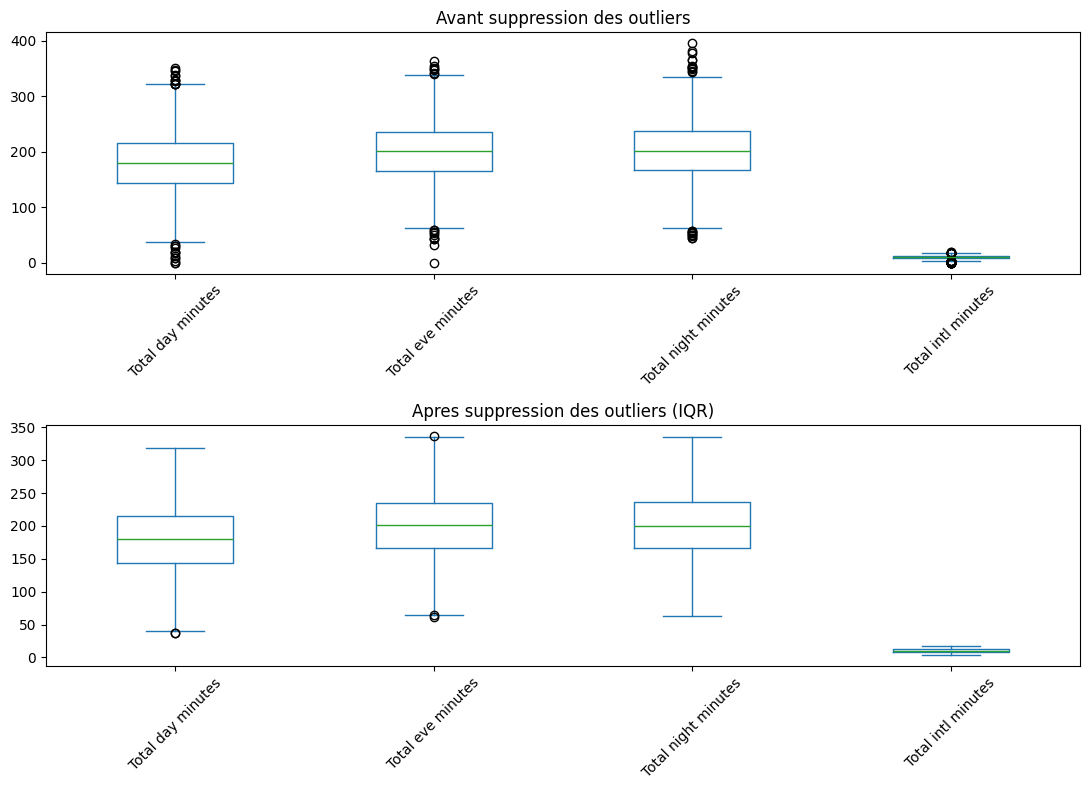

  [PLOT] Codveda_DataScience_Project/outputs/level1/cleaning_boxplots_before_after.png

------------------------------------------------------------
4) STANDARDISATION DES VARIABLES NUMERIQUES (StandardScaler)
------------------------------------------------------------
  15 colonnes standardisees (moyenne ~0, ecart-type ~1).
  Verification (moyenne / std des 3 premieres) :
      Account length  Number vmail messages  Total day minutes
mean            -0.0                   -0.0               -0.0
std              1.0                    1.0                1.0

[SAVE] Dataset nettoye -> Codveda_DataScience_Project/data/processed/churn_cleaned.csv
       Dimensions finales : 2247 lignes x 70 colonnes
Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 1 (Basic) - Task 2 : Data Cleaning and Preprocessing
============================================================================
Dataset : data/raw/churn_train.csv  (Telecom Customer Churn, 2666 lignes)

Objectifs couverts :
  - Gerer les valeurs manquantes (detection + imputation / suppression)
  - Detecter et supprimer les valeurs aberrantes (outliers, methode IQR)
  - Convertir les variables categorielles en numerique
        (One-Hot Encoding + Label / Binary Encoding)
  - Normaliser / standardiser les variables numeriques (StandardScaler)

Sorties :
  - data/processed/churn_cleaned.csv
  - outputs/level1/cleaning_boxplots_before_after.png
============================================================================
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path("Codveda_DataScience_Project")
RAW = PROJECT_ROOT / "data" / "raw" / "churn_train.csv"
PROC_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR = PROJECT_ROOT / "outputs" / "level1"
PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def load_data() -> pd.DataFrame:
    df = pd.read_csv(RAW)
    print(f"[LOAD] {RAW.name} -> {df.shape[0]} lignes, {df.shape[1]} colonnes")
    return df


def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detection + traitement des valeurs manquantes.

    Le dataset d'origine ne contient AUCUNE valeur manquante. Pour demontrer
    la technique d'imputation exigee par la tache, on injecte volontairement
    ~2% de NaN dans deux colonnes numeriques, puis on les impute par la mediane.
    (Bloc de demonstration clairement identifie.)
    """
    print("\n" + "-" * 60)
    print("1) VALEURS MANQUANTES")
    print("-" * 60)
    print("Valeurs manquantes initiales :", int(df.isna().sum().sum()))

    rng = np.random.default_rng(RANDOM_STATE)
    demo_cols = ["Total day minutes", "Customer service calls"]
    for col in demo_cols:
        idx = rng.choice(df.index, size=int(0.02 * len(df)), replace=False)
        df.loc[idx, col] = np.nan
    print(f"[demo] Injection de NaN dans {demo_cols} :")
    print(df[demo_cols].isna().sum().to_string())

    # Imputation par la mediane (robuste aux valeurs extremes)
    for col in demo_cols:
        median = df[col].median()
        df[col] = df[col].fillna(median)
        print(f"  -> '{col}' impute par la mediane = {median}")

    print("Valeurs manquantes apres imputation :", int(df.isna().sum().sum()))
    return df


def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    """Conversion des variables categorielles en numerique."""
    print("\n" + "-" * 60)
    print("2) ENCODAGE DES VARIABLES CATEGORIELLES")
    print("-" * 60)

    # a) Binaire (Yes/No -> 1/0) : Label/Binary Encoding
    for col in ["International plan", "Voice mail plan"]:
        df[col] = df[col].map({"Yes": 1, "No": 0}).astype(int)
        print(f"  [binary]  {col} -> 0/1")

    # b) Cible booleenne -> entier
    df["Churn"] = df["Churn"].astype(int)
    print("  [target]  Churn (True/False) -> 1/0")

    # c) One-Hot Encoding pour la variable a nombreuses categories : State
    n_states = df["State"].nunique()
    df = pd.get_dummies(df, columns=["State"], prefix="State", dtype=int)
    print(f"  [one-hot] State ({n_states} categories) -> {n_states} colonnes indicatrices")

    return df


def detect_remove_outliers(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Detection + suppression des outliers par la methode de l'ecart interquartile (IQR)."""
    print("\n" + "-" * 60)
    print("3) DETECTION & SUPPRESSION DES OUTLIERS (methode IQR)")
    print("-" * 60)

    before = len(df)
    mask = pd.Series(True, index=df.index)
    total_flagged = 0
    for col in cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (df[col] < low) | (df[col] > high)
        total_flagged += int(col_out.sum())
        mask &= ~col_out

    df_clean = df[mask].copy()
    print(f"  Outliers detectes (toutes colonnes) : {total_flagged}")
    print(f"  Lignes supprimees : {before - len(df_clean)}  ({before} -> {len(df_clean)})")
    return df_clean


def plot_boxplots(df_before: pd.DataFrame, df_after: pd.DataFrame, cols: list[str]) -> None:
    """Boxplots avant / apres suppression des outliers."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 8))
    df_before[cols].plot(kind="box", ax=axes[0], rot=45)
    axes[0].set_title("Avant suppression des outliers")
    df_after[cols].plot(kind="box", ax=axes[1], rot=45)
    axes[1].set_title("Apres suppression des outliers (IQR)")
    fig.tight_layout()
    path = OUT_DIR / "cleaning_boxplots_before_after.png"
    fig.savefig(path, dpi=120)
    plt.show()
    print(f"  [PLOT] {path}")


def standardize(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Standardisation (moyenne 0, ecart-type 1) des colonnes numeriques."""
    print("\n" + "-" * 60)
    print("4) STANDARDISATION DES VARIABLES NUMERIQUES (StandardScaler)")
    print("-" * 60)
    scaler = StandardScaler()
    df[cols] = scaler.fit_transform(df[cols])
    print(f"  {len(cols)} colonnes standardisees (moyenne ~0, ecart-type ~1).")
    print("  Verification (moyenne / std des 3 premieres) :")
    print(df[cols[:3]].agg(["mean", "std"]).round(3).to_string())
    return df


def main() -> None:
    print("=" * 70)
    print("LEVEL 1 - TASK 2 : DATA CLEANING & PREPROCESSING")
    print("=" * 70)

    df = load_data()

    numeric_cols = [
        "Account length", "Number vmail messages", "Total day minutes",
        "Total day calls", "Total day charge", "Total eve minutes",
        "Total eve calls", "Total eve charge", "Total night minutes",
        "Total night calls", "Total night charge", "Total intl minutes",
        "Total intl calls", "Total intl charge", "Customer service calls",
    ]
    plot_cols = ["Total day minutes", "Total eve minutes",
                 "Total night minutes", "Total intl minutes"]

    df = handle_missing(df)
    df = encode_categoricals(df)

    df_before_outliers = df.copy()
    df = detect_remove_outliers(df, numeric_cols)
    plot_boxplots(df_before_outliers, df, plot_cols)

    df = standardize(df, numeric_cols)

    out_path = PROC_DIR / "churn_cleaned.csv"
    df.to_csv(out_path, index=False)
    print("\n" + "=" * 70)
    print(f"[SAVE] Dataset nettoye -> {out_path}")
    print(f"       Dimensions finales : {df.shape[0]} lignes x {df.shape[1]} colonnes")
    print("Termine avec succes.")



main()


## Niveau 1 — Tâche 3 : Analyse Exploratoire (EDA)

Statistiques descriptives, histogrammes, box plots par churn, matrice de corrélation, rapport `reports/EDA_report.md`.

LEVEL 1 - TASK 3 : EXPLORATORY DATA ANALYSIS (EDA)
[LOAD] churn_train.csv -> (2666, 20)

------------------------------------------------------------
1) STATISTIQUES DESCRIPTIVES
------------------------------------------------------------
                         count    mean  median    std  variance     min     25%     50%     75%     max  skew
Account length          2666.0  100.62  100.00  39.56   1565.31    1.00   73.00  100.00  127.00  243.00  0.08
Area code               2666.0  437.44  415.00  42.52   1808.04  408.00  408.00  415.00  510.00  510.00  1.11
Number vmail messages   2666.0    8.02    0.00  13.61    185.29    0.00    0.00    0.00   19.00   50.00  1.27
Total day minutes       2666.0  179.48  179.95  54.21   2938.76    0.00  143.40  179.95  215.90  350.80 -0.05
Total day calls         2666.0  100.31  101.00  19.99    399.53    0.00   87.00  101.00  114.00  160.00 -0.13
Total day charge        2666.0   30.51   30.59   9.22     84.93    0.00   24.38   30.59   36.70   59

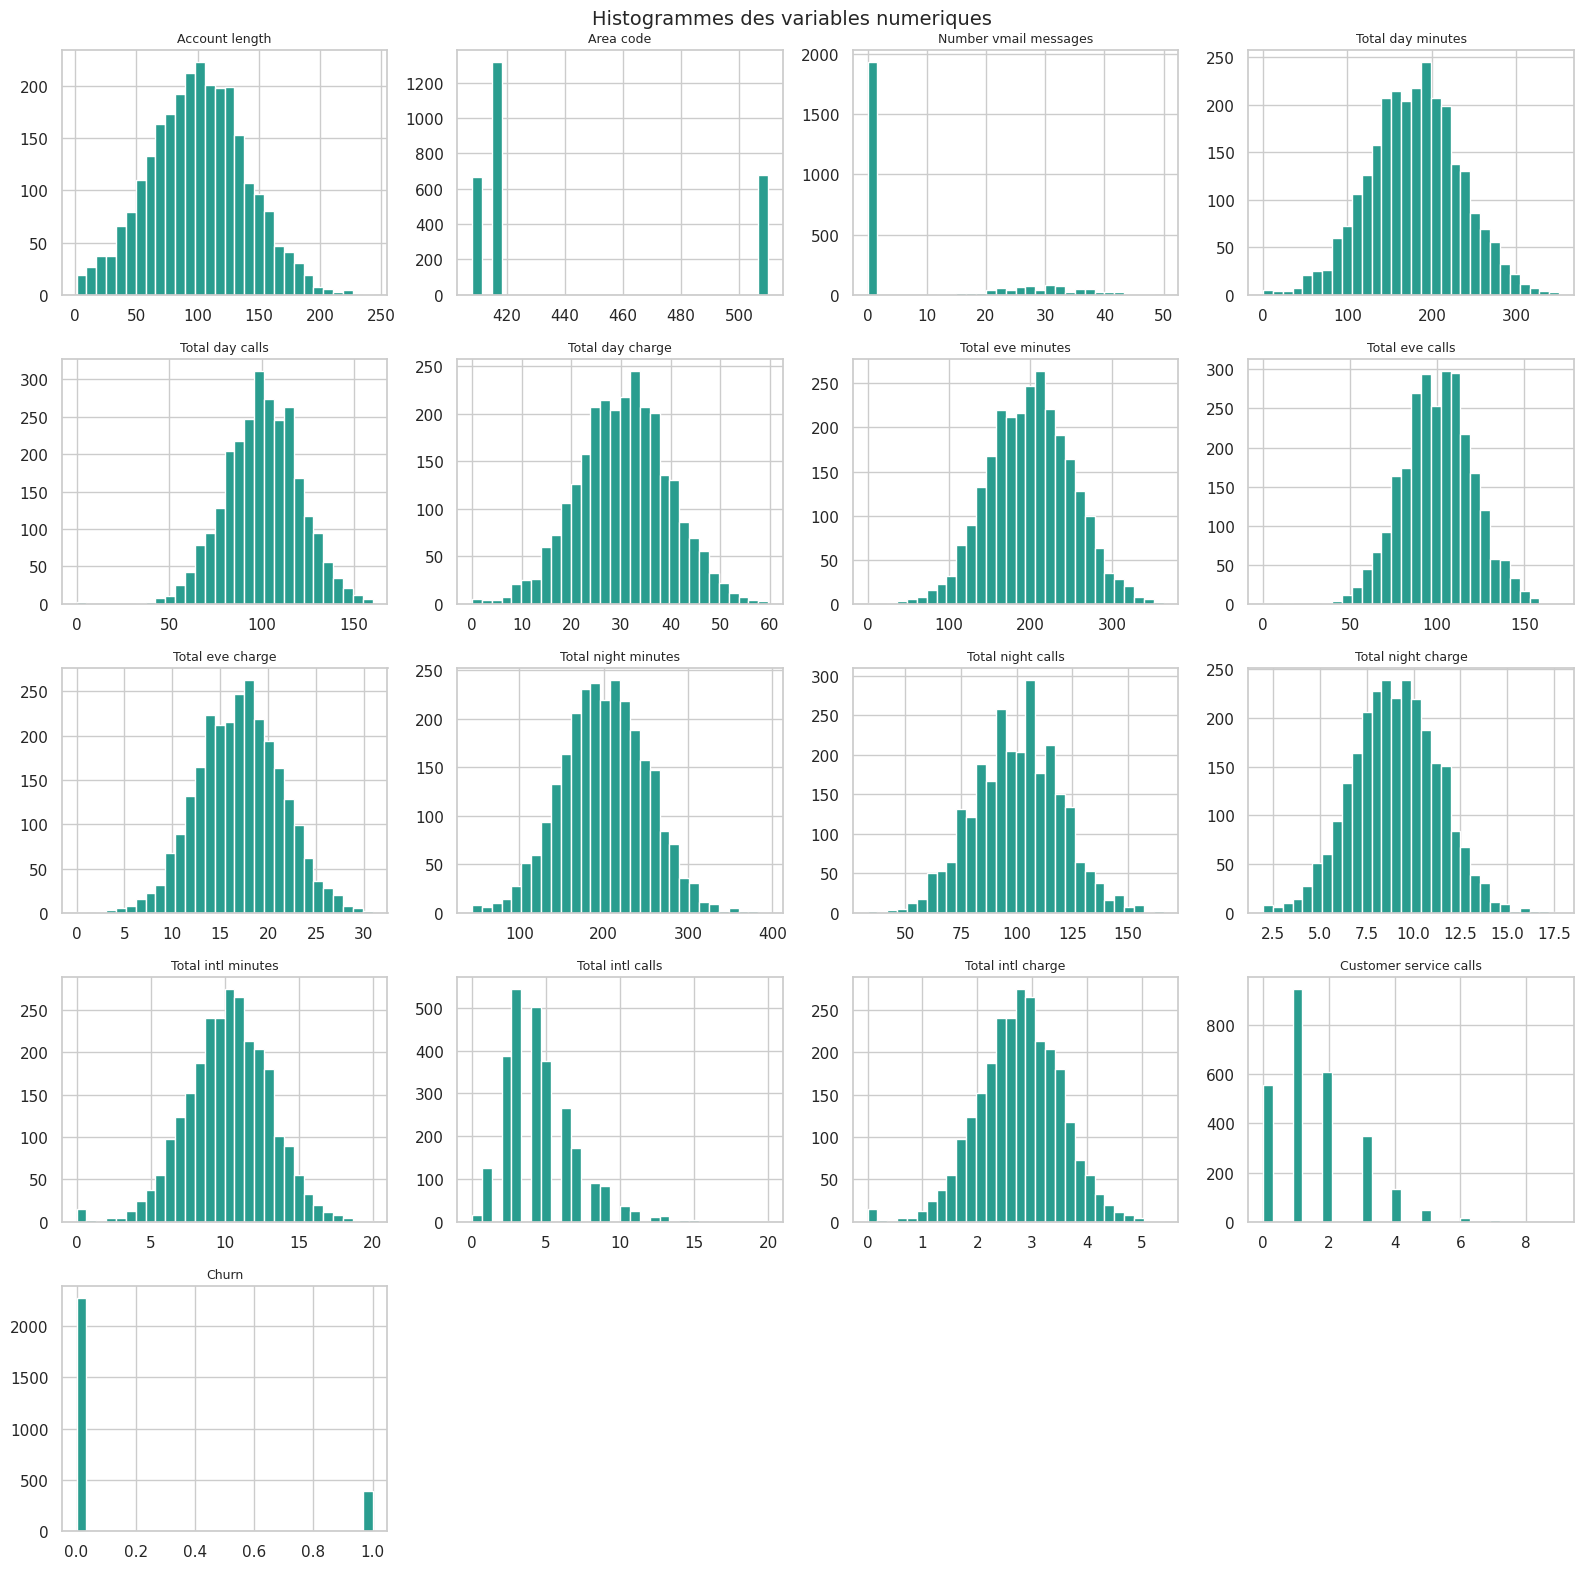

  [PLOT] Codveda_DataScience_Project/outputs/level1/eda_histograms.png


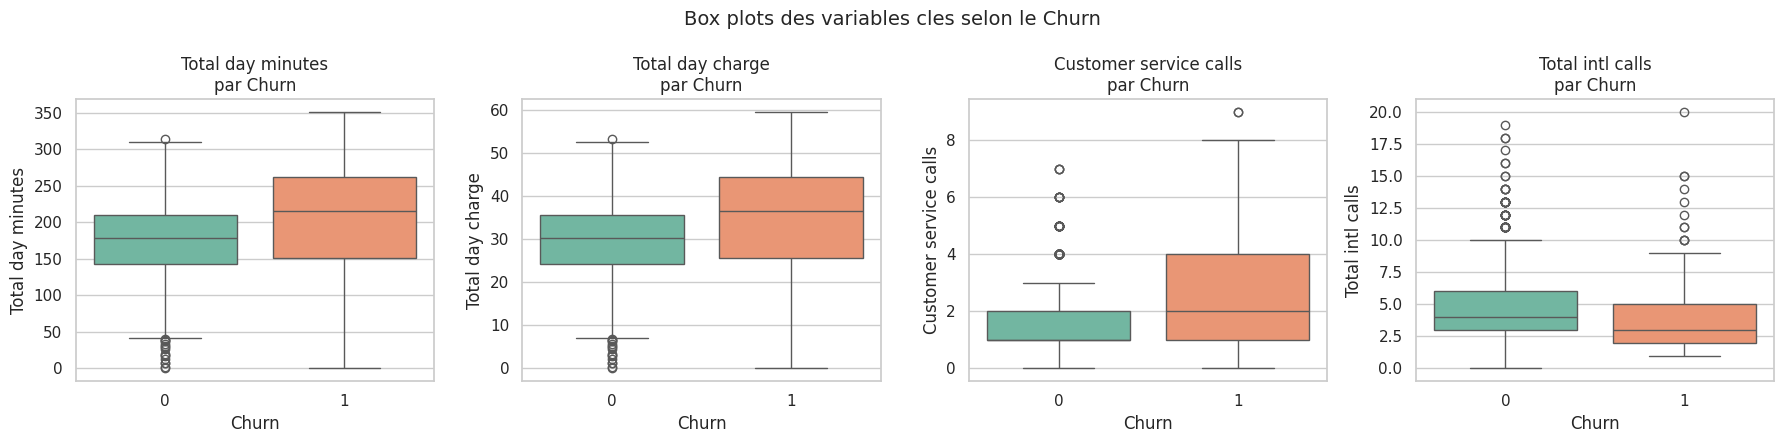

  [PLOT] Codveda_DataScience_Project/outputs/level1/eda_boxplots_by_churn.png


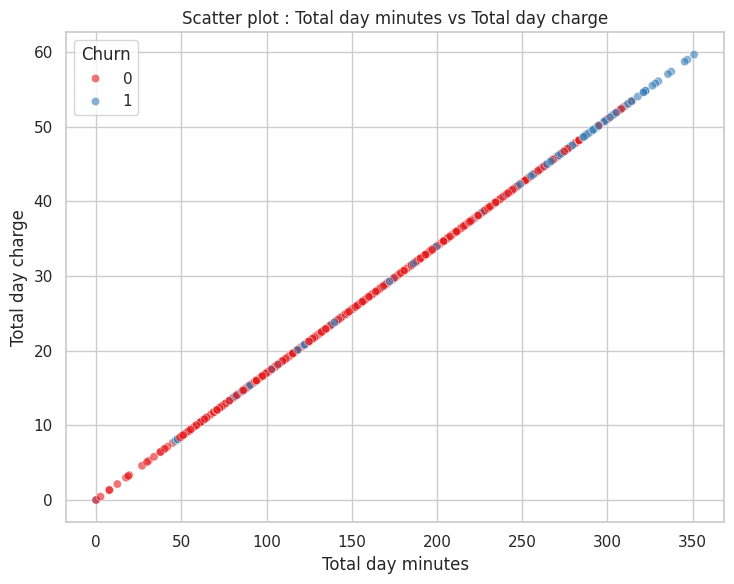

  [PLOT] Codveda_DataScience_Project/outputs/level1/eda_scatter_matrix.png

------------------------------------------------------------
2) MATRICE DE CORRELATION
------------------------------------------------------------


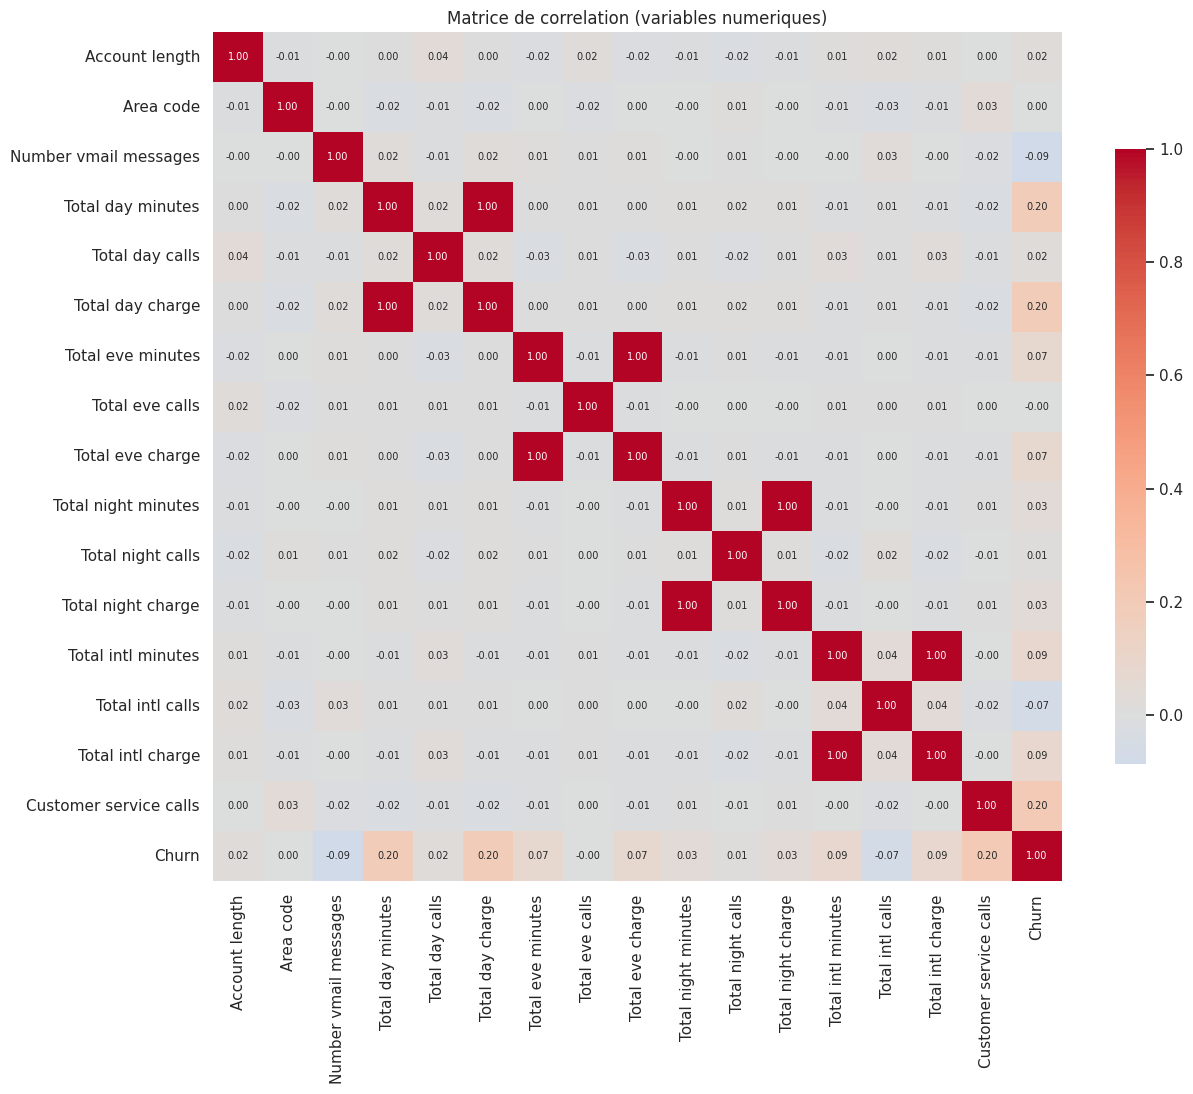

  [PLOT] Codveda_DataScience_Project/outputs/level1/eda_correlation_matrix.png

Top 6 correlations (valeur absolue) :
Total day minutes       Total day charge       1.000
Total eve charge        Total eve minutes      1.000
Total night charge      Total night minutes    1.000
Total intl charge       Total intl minutes     1.000
Customer service calls  Churn                  0.203
Total day charge        Churn                  0.196

[REPORT] Codveda_DataScience_Project/reports/EDA_report.md

Termine avec succes.


/tmp/ipykernel_1782/2012416150.py:176: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{intl_churn.get(1, float('nan')):.1f} % pour les clients AVEC forfait "
/tmp/ipykernel_1782/2012416150.py:177: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"international, contre {intl_churn.get(0, float('nan')):.1f} % sans. Les "


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 1 (Basic) - Task 3 : Exploratory Data Analysis (EDA)
============================================================================
Dataset : data/raw/churn_train.csv  (Telecom Customer Churn)

Objectifs couverts :
  - Calculer les statistiques descriptives (moyenne, mediane, variance...)
  - Visualiser les donnees (histogrammes, scatter plots, box plots)
  - Identifier les correlations (matrice de correlation)
  - Generer un rapport resumant les enseignements de l'EDA

Sorties :
  - outputs/level1/eda_histograms.png
  - outputs/level1/eda_boxplots_by_churn.png
  - outputs/level1/eda_scatter_matrix.png
  - outputs/level1/eda_correlation_matrix.png
  - reports/EDA_report.md
============================================================================
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("Codveda_DataScience_Project")
RAW = PROJECT_ROOT / "data" / "raw" / "churn_train.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "level1"
REPORT_DIR = PROJECT_ROOT / "reports"
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def summary_statistics(df: pd.DataFrame) -> pd.DataFrame:
    print("\n" + "-" * 60)
    print("1) STATISTIQUES DESCRIPTIVES")
    print("-" * 60)
    num = df.select_dtypes(include=[np.number])
    stats = num.describe().T
    stats["median"] = num.median()
    stats["variance"] = num.var()
    stats["skew"] = num.skew()
    stats = stats[["count", "mean", "median", "std", "variance",
                   "min", "25%", "50%", "75%", "max", "skew"]]
    print(stats.round(2).to_string())
    return stats


def plot_histograms(df: pd.DataFrame) -> None:
    num_cols = df.select_dtypes(include=[np.number]).columns
    n = len(num_cols)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
    axes = axes.ravel()
    for i, col in enumerate(num_cols):
        axes[i].hist(df[col], bins=30, color="#2a9d8f", edgecolor="white")
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    fig.suptitle("Histogrammes des variables numeriques", fontsize=14)
    fig.tight_layout()
    p = OUT_DIR / "eda_histograms.png"
    fig.savefig(p, dpi=110)
    plt.show()
    print(f"  [PLOT] {p}")


def plot_boxplots_by_target(df: pd.DataFrame) -> None:
    cols = ["Total day minutes", "Total day charge",
            "Customer service calls", "Total intl calls"]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for ax, col in zip(axes, cols):
        sns.boxplot(data=df, x="Churn", y=col, ax=ax, palette="Set2", hue="Churn", legend=False)
        ax.set_title(f"{col}\npar Churn")
    fig.suptitle("Box plots des variables cles selon le Churn", fontsize=14)
    fig.tight_layout()
    p = OUT_DIR / "eda_boxplots_by_churn.png"
    fig.savefig(p, dpi=110)
    plt.show()
    print(f"  [PLOT] {p}")


def plot_scatter(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 6))
    sns.scatterplot(
        data=df, x="Total day minutes", y="Total day charge",
        hue="Churn", palette="Set1", alpha=0.6, ax=ax,
    )
    ax.set_title("Scatter plot : Total day minutes vs Total day charge")
    fig.tight_layout()
    p = OUT_DIR / "eda_scatter_matrix.png"
    fig.savefig(p, dpi=110)
    plt.show()
    print(f"  [PLOT] {p}")


def plot_correlation(df: pd.DataFrame) -> pd.DataFrame:
    print("\n" + "-" * 60)
    print("2) MATRICE DE CORRELATION")
    print("-" * 60)
    num = df.select_dtypes(include=[np.number])
    corr = num.corr()

    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, cbar_kws={"shrink": 0.7}, annot_kws={"size": 7}, ax=ax)
    ax.set_title("Matrice de correlation (variables numeriques)")
    fig.tight_layout()
    p = OUT_DIR / "eda_correlation_matrix.png"
    fig.savefig(p, dpi=110)
    plt.show()
    print(f"  [PLOT] {p}")

    # Paires les plus correlees (hors diagonale)
    corr_pairs = (
        corr.where(~np.eye(len(corr), dtype=bool))
        .stack()
        .sort_values(key=abs, ascending=False)
    )
    corr_pairs = corr_pairs[::2]  # chaque paire apparait 2x
    print("\nTop 6 correlations (valeur absolue) :")
    print(corr_pairs.head(6).round(3).to_string())
    return corr


def write_report(df: pd.DataFrame, stats: pd.DataFrame, corr: pd.DataFrame) -> None:
    churn_rate = df["Churn"].mean() * 100
    n = len(df)

    # Comparaison churn vs non-churn sur quelques variables
    grp = df.groupby("Churn")[["Customer service calls", "Total day minutes",
                               "Total day charge"]].mean()

    intl_churn = df.groupby("International plan")["Churn"].mean() * 100

    lines = []
    lines.append("# Rapport d'Analyse Exploratoire (EDA)\n")
    lines.append("**Projet Codveda - Level 1 / Task 3**  \n")
    lines.append(f"**Dataset :** Telecom Customer Churn (`churn_train.csv`) - "
                 f"{n} lignes, {df.shape[1]} colonnes\n")
    lines.append("---\n")

    lines.append("## 1. Vue d'ensemble\n")
    lines.append(f"- Taux de churn global : **{churn_rate:.1f} %** "
                 f"({int(df['Churn'].sum())} clients partis sur {n}).\n")
    lines.append("- Le jeu de donnees est **desequilibre** : la majorite des clients restent.\n")
    lines.append("- Aucune valeur manquante dans le dataset brut.\n")

    lines.append("\n## 2. Statistiques descriptives (extrait)\n")
    lines.append("| Variable | Moyenne | Mediane | Ecart-type | Min | Max |")
    lines.append("|---|---|---|---|---|---|")
    for col in ["Account length", "Total day minutes", "Total day charge",
                "Customer service calls", "Total intl calls"]:
        r = stats.loc[col]
        lines.append(f"| {col} | {r['mean']:.2f} | {r['median']:.2f} | "
                     f"{r['std']:.2f} | {r['min']:.2f} | {r['max']:.2f} |")

    lines.append("\n## 3. Enseignements cles\n")
    lines.append(f"1. **Appels au service client** : les clients qui partent appellent "
                 f"en moyenne {grp.loc[1, 'Customer service calls']:.2f} fois le service "
                 f"client, contre {grp.loc[0, 'Customer service calls']:.2f} pour ceux qui "
                 f"restent. C'est un signal d'insatisfaction fort.\n")
    lines.append(f"2. **Consommation en journee** : les clients partis consomment davantage "
                 f"en journee ({grp.loc[1, 'Total day minutes']:.1f} min vs "
                 f"{grp.loc[0, 'Total day minutes']:.1f} min) et paient donc plus cher.\n")
    lines.append(f"3. **Forfait international** : le taux de churn est de "
                 f"{intl_churn.get(1, float('nan')):.1f} % pour les clients AVEC forfait "
                 f"international, contre {intl_churn.get(0, float('nan')):.1f} % sans. Les "
                 f"abonnes internationaux sont bien plus a risque.\n")
    lines.append("4. **Correlations** : les colonnes `minutes` et `charge` (jour/soir/nuit/"
                 "intl) sont quasi parfaitement correlees (~1.0), car la facturation est "
                 "proportionnelle aux minutes. Ce sont des variables redondantes -> on peut en "
                 "supprimer une par paire pour la modelisation.\n")

    lines.append("\n## 4. Recommandations pour la modelisation\n")
    lines.append("- Supprimer les colonnes `charge` redondantes (colineaires avec `minutes`).\n")
    lines.append("- Gerer le desequilibre de classes (class_weight, SMOTE, ou stratification).\n")
    lines.append("- Variables les plus prometteuses : `Customer service calls`, "
                 "`Total day minutes`, `International plan`.\n")

    lines.append("\n## 5. Figures generees\n")
    lines.append("- `outputs/level1/eda_histograms.png`\n")
    lines.append("- `outputs/level1/eda_boxplots_by_churn.png`\n")
    lines.append("- `outputs/level1/eda_scatter_matrix.png`\n")
    lines.append("- `outputs/level1/eda_correlation_matrix.png`\n")

    path = REPORT_DIR / "EDA_report.md"
    path.write_text("\n".join(lines), encoding="utf-8")
    print(f"\n[REPORT] {path}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 1 - TASK 3 : EXPLORATORY DATA ANALYSIS (EDA)")
    print("=" * 70)

    df = pd.read_csv(RAW)
    df["Churn"] = df["Churn"].astype(int)
    print(f"[LOAD] {RAW.name} -> {df.shape}")

    stats = summary_statistics(df)
    plot_histograms(df)
    plot_boxplots_by_target(df)
    plot_scatter(df)
    corr = plot_correlation(df)
    write_report(df, stats, corr)

    print("\nTermine avec succes.")



main()


## Niveau 2 — Tâche 1 : Régression (Boston Housing)

Linear / Decision Tree / Random Forest, R²/MSE, importance des variables. Random Forest ≈ meilleur R².

LEVEL 2 - TASK 1 : PREDICTIVE MODELING (REGRESSION)
[LOAD] house_prediction.csv reformate -> 506 lignes, 14 colonnes
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO       B  LSTAT  MEDV
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0     15.3  396.90   4.98  24.0
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0     17.8  396.90   9.14  21.6
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0     17.8  392.83   4.03  34.7

[SPLIT] train=404  test=102

------------------------------------------------------------
ENTRAINEMENT & EVALUATION
------------------------------------------------------------
  Linear Regression     MSE=  24.291  RMSE= 4.929  R2=0.669
  Decision Tree         MSE=   8.929  RMSE= 2.988  R2=0.878
  Random Forest         MSE=   8.510  RMSE= 2.917  R2=0.884

------------------------------------------------------------
COMPARAISON DES MODELES
---------------------------------------

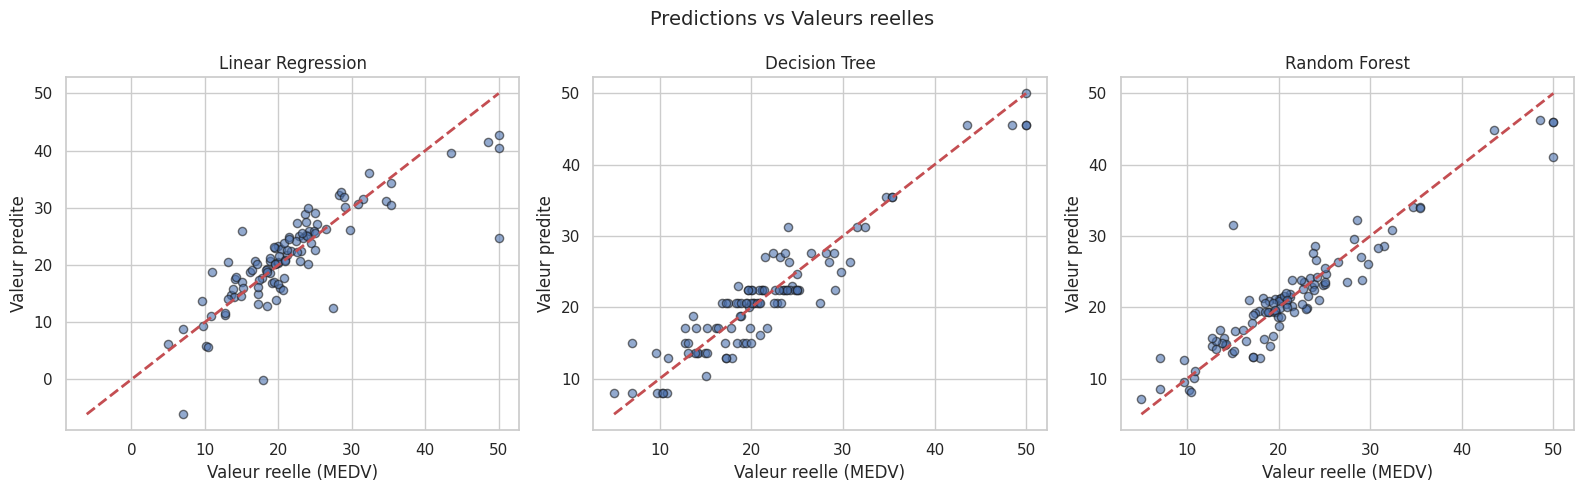

  [PLOT] Codveda_DataScience_Project/outputs/level2/regression_pred_vs_actual.png


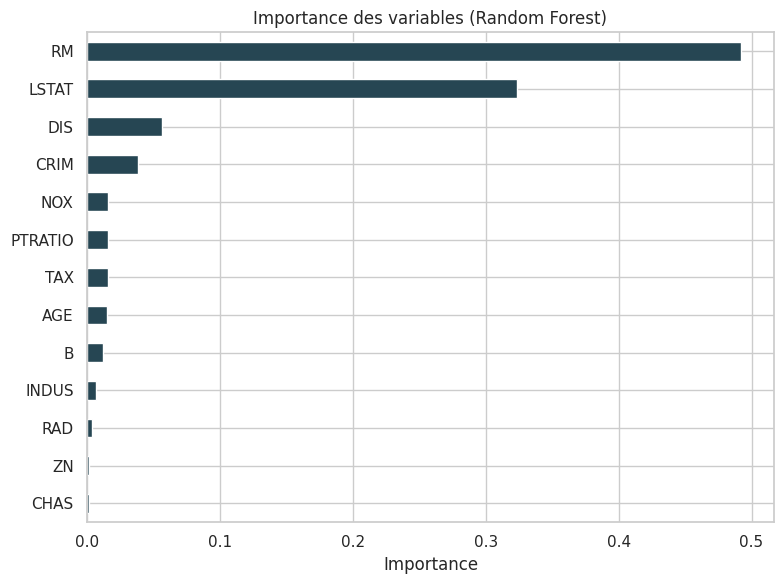

  [PLOT] Codveda_DataScience_Project/outputs/level2/regression_feature_importance.png

Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 2 (Intermediate) - Task 1 : Predictive Modeling (Regression)
============================================================================
Dataset : data/raw/house_prediction.csv  (Boston Housing, 506 lignes)
Cible   : MEDV = prix median des logements (en milliers de $)

Le fichier brut est en fait separe par des ESPACES et SANS en-tete
(colonnes classiques du Boston Housing). Le script le reformate proprement.

Objectifs couverts :
  - Separer le dataset en jeux d'entrainement / test
  - Entrainer une regression lineaire (scikit-learn)
  - Evaluer avec MSE et R-squared
  - Experimenter plusieurs modeles (Decision Tree, Random Forest) et comparer

Sorties :
  - outputs/level2/regression_pred_vs_actual.png
  - outputs/level2/regression_feature_importance.png
  - outputs/level2/regression_metrics.csv
============================================================================
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

PROJECT_ROOT = Path("Codveda_DataScience_Project")
RAW = PROJECT_ROOT / "data" / "raw" / "house_prediction.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "level2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

COLUMNS = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
           "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]


def load_data() -> pd.DataFrame:
    """Le fichier est separe par des espaces et sans en-tete -> on le reformate."""
    df = pd.read_csv(RAW, header=None, sep=r"\s+", engine="python")
    df.columns = COLUMNS
    print(f"[LOAD] {RAW.name} reformate -> {df.shape[0]} lignes, {df.shape[1]} colonnes")
    print(df.head(3).to_string())
    return df


def evaluate(name, model, X_tr, X_te, y_tr, y_te) -> dict:
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mse = mean_squared_error(y_te, pred)
    metrics = {
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_te, pred),
        "R2": r2_score(y_te, pred),
    }
    print(f"  {name:<20}  MSE={metrics['MSE']:8.3f}  "
          f"RMSE={metrics['RMSE']:6.3f}  R2={metrics['R2']:.3f}")
    return metrics, pred


def plot_pred_vs_actual(results: dict, y_te) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (name, pred) in zip(axes, results.items()):
        ax.scatter(y_te, pred, alpha=0.6, edgecolor="k", s=35)
        lims = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
        ax.plot(lims, lims, "r--", lw=2)
        ax.set_xlabel("Valeur reelle (MEDV)")
        ax.set_ylabel("Valeur predite")
        ax.set_title(name)
    fig.suptitle("Predictions vs Valeurs reelles", fontsize=14)
    fig.tight_layout()
    p = OUT_DIR / "regression_pred_vs_actual.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def plot_feature_importance(rf: RandomForestRegressor, feature_names) -> None:
    imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
    fig, ax = plt.subplots(figsize=(8, 6))
    imp.plot(kind="barh", color="#264653", ax=ax)
    ax.set_title("Importance des variables (Random Forest)")
    ax.set_xlabel("Importance")
    fig.tight_layout()
    p = OUT_DIR / "regression_feature_importance.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 2 - TASK 1 : PREDICTIVE MODELING (REGRESSION)")
    print("=" * 70)

    df = load_data()
    X = df.drop(columns=["MEDV"])
    y = df["MEDV"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    print(f"\n[SPLIT] train={X_tr.shape[0]}  test={X_te.shape[0]}")

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=6),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    }

    print("\n" + "-" * 60)
    print("ENTRAINEMENT & EVALUATION")
    print("-" * 60)
    all_metrics, preds = [], {}
    for name, model in models.items():
        m, pred = evaluate(name, model, X_tr, X_te, y_tr, y_te)
        all_metrics.append(m)
        preds[name] = pred

    metrics_df = pd.DataFrame(all_metrics).set_index("Model").round(4)
    best = metrics_df["R2"].idxmax()

    print("\n" + "-" * 60)
    print("COMPARAISON DES MODELES")
    print("-" * 60)
    print(metrics_df.to_string())
    print(f"\n>> Meilleur modele (R2) : {best}")

    metrics_df.to_csv(OUT_DIR / "regression_metrics.csv")
    print(f"[SAVE] {OUT_DIR / 'regression_metrics.csv'}")

    plot_pred_vs_actual(preds, y_te)
    plot_feature_importance(models["Random Forest"], X.columns)

    print("\nTermine avec succes.")



main()


## Niveau 2 — Tâche 2 : Classification (Iris)

Logistic Regression / Random Forest / SVM, accuracy/precision/recall/F1, matrices de confusion, courbes ROC.

LEVEL 2 - TASK 2 : CLASSIFICATION (LOGISTIC REGRESSION)
[LOAD] iris.csv -> (150, 5)
  Classes : {'setosa': 0, 'versicolor': 1, 'virginica': 2}
  [SPLIT] train=112  test=38  (features standardisees)

------------------------------------------------------------
ENTRAINEMENT & EVALUATION
------------------------------------------------------------
  Logistic Regression    acc=0.921  prec=0.925  rec=0.923  f1=0.923
  Random Forest          acc=0.921  prec=0.925  rec=0.923  f1=0.923
  SVM (RBF)              acc=0.947  prec=0.949  rec=0.949  f1=0.949

------------------------------------------------------------
COMPARAISON DES MODELES
------------------------------------------------------------
                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.9211     0.9246  0.9231  0.9230
Random Forest          0.9211     0.9246  0.9231  0.9230
SVM (RBF)              0.9474     0.9487  0.9487  0.9487
[SAVE] Codveda_Da

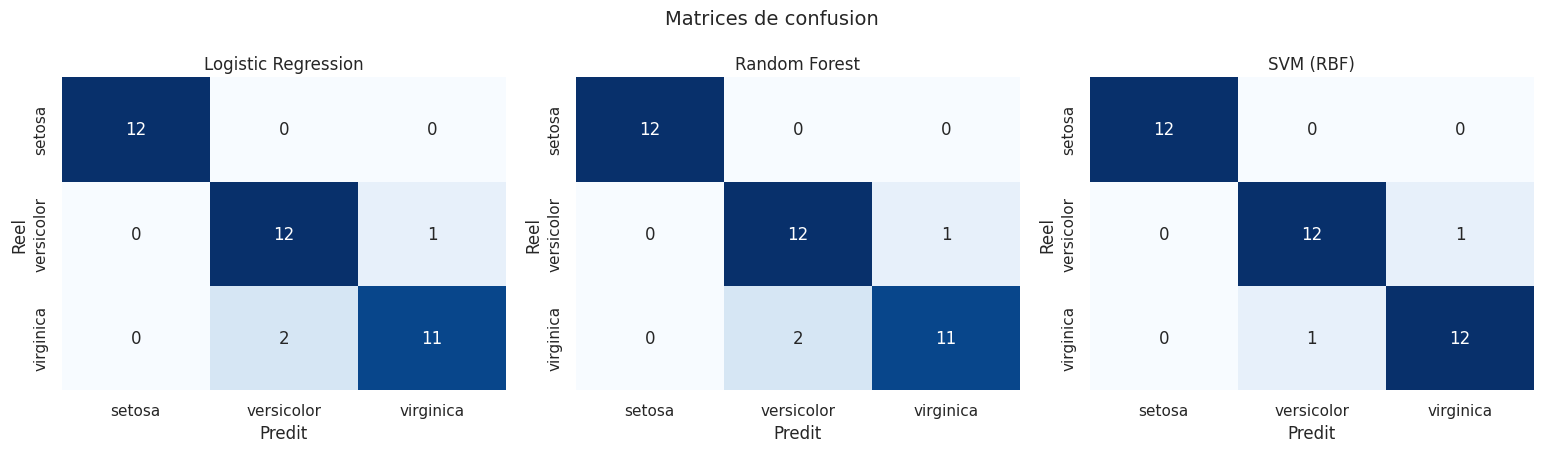

  [PLOT] Codveda_DataScience_Project/outputs/level2/classification_confusion_matrices.png


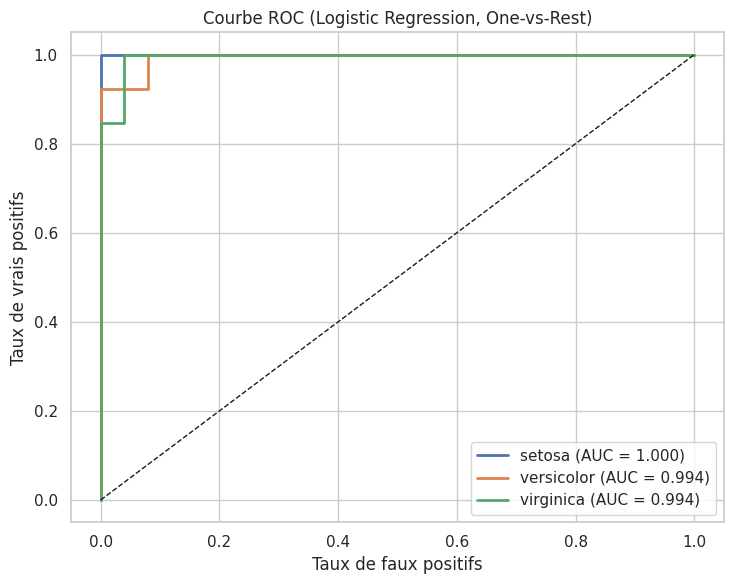

  [PLOT] Codveda_DataScience_Project/outputs/level2/classification_roc_curves.png

Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 2 (Intermediate) - Task 2 : Classification (Logistic Regression)
============================================================================
Dataset : data/raw/iris.csv  (150 fleurs, 3 especes)
Cible   : species (setosa / versicolor / virginica)

Objectifs couverts :
  - Pretraiter les donnees (encodage cible + feature scaling)
  - Entrainer et evaluer une regression logistique
  - Metriques : accuracy, precision, recall + courbe ROC
  - Comparer avec d'autres classifieurs (Random Forest, SVM)

Sorties :
  - outputs/level2/classification_confusion_matrices.png
  - outputs/level2/classification_roc_curves.png
  - outputs/level2/classification_metrics.csv
============================================================================
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

PROJECT_ROOT = Path("Codveda_DataScience_Project")
RAW = PROJECT_ROOT / "data" / "raw" / "iris.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "level2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def load_and_preprocess():
    df = pd.read_csv(RAW)
    print(f"[LOAD] {RAW.name} -> {df.shape}")

    X = df.drop(columns=["species"])
    # Encodage de la cible (label encoding : setosa=0, versicolor=1, virginica=2)
    classes = sorted(df["species"].unique())
    class_to_int = {c: i for i, c in enumerate(classes)}
    y = df["species"].map(class_to_int).values
    print(f"  Classes : {class_to_int}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )

    # Feature scaling (important pour la reg. logistique et le SVM)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    print(f"  [SPLIT] train={len(y_tr)}  test={len(y_te)}  (features standardisees)")
    return X_tr_s, X_te_s, y_tr, y_te, classes


def evaluate(name, model, X_tr, X_te, y_tr, y_te) -> dict:
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    m = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, average="macro"),
        "Recall": recall_score(y_te, pred, average="macro"),
        "F1": f1_score(y_te, pred, average="macro"),
    }
    print(f"  {name:<22} acc={m['Accuracy']:.3f}  "
          f"prec={m['Precision']:.3f}  rec={m['Recall']:.3f}  f1={m['F1']:.3f}")
    return m, pred


def plot_confusion_matrices(models_preds, y_te, classes) -> None:
    n = len(models_preds)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.6))
    for ax, (name, pred) in zip(axes, models_preds.items()):
        cm = confusion_matrix(y_te, pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Predit")
        ax.set_ylabel("Reel")
    fig.suptitle("Matrices de confusion", fontsize=14)
    fig.tight_layout()
    p = OUT_DIR / "classification_confusion_matrices.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def plot_roc(models, X_te, y_te, classes) -> None:
    """Courbe ROC one-vs-rest (multiclasse) pour la regression logistique."""
    y_bin = label_binarize(y_te, classes=list(range(len(classes))))
    fig, ax = plt.subplots(figsize=(7.5, 6))

    lr = models["Logistic Regression"]
    y_score = lr.predict_proba(X_te)
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("Taux de faux positifs")
    ax.set_ylabel("Taux de vrais positifs")
    ax.set_title("Courbe ROC (Logistic Regression, One-vs-Rest)")
    ax.legend(loc="lower right")
    fig.tight_layout()
    p = OUT_DIR / "classification_roc_curves.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 2 - TASK 2 : CLASSIFICATION (LOGISTIC REGRESSION)")
    print("=" * 70)

    X_tr, X_te, y_tr, y_te, classes = load_and_preprocess()

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    }

    print("\n" + "-" * 60)
    print("ENTRAINEMENT & EVALUATION")
    print("-" * 60)
    all_metrics, preds = [], {}
    for name, model in models.items():
        m, pred = evaluate(name, model, X_tr, X_te, y_tr, y_te)
        all_metrics.append(m)
        preds[name] = pred

    metrics_df = pd.DataFrame(all_metrics).set_index("Model").round(4)
    print("\n" + "-" * 60)
    print("COMPARAISON DES MODELES")
    print("-" * 60)
    print(metrics_df.to_string())
    metrics_df.to_csv(OUT_DIR / "classification_metrics.csv")
    print(f"[SAVE] {OUT_DIR / 'classification_metrics.csv'}")

    print("\nRapport detaille (Logistic Regression) :")
    print(classification_report(y_te, preds["Logistic Regression"], target_names=classes))

    plot_confusion_matrices(preds, y_te, classes)
    plot_roc(models, X_te, y_te, classes)

    print("\nTermine avec succes.")



main()


## Niveau 2 — Tâche 3 : Clustering K-Means (Iris)

Méthode du coude + silhouette pour choisir k, visualisation PCA 2D, comparaison aux vraies espèces (ARI).

LEVEL 2 - TASK 3 : CLUSTERING (K-MEANS)
[LOAD] iris.csv -> (150, 5) (colonne 'species' ignoree)

------------------------------------------------------------
1) RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS
------------------------------------------------------------
  k=2  inertie=  223.73  silhouette=0.580
  k=3  inertie=  140.97  silhouette=0.459
  k=4  inertie=  114.62  silhouette=0.385
  k=5  inertie=   91.30  silhouette=0.347
  k=6  inertie=   81.76  silhouette=0.341
  k=7  inertie=   71.32  silhouette=0.329
  k=8  inertie=   62.65  silhouette=0.340


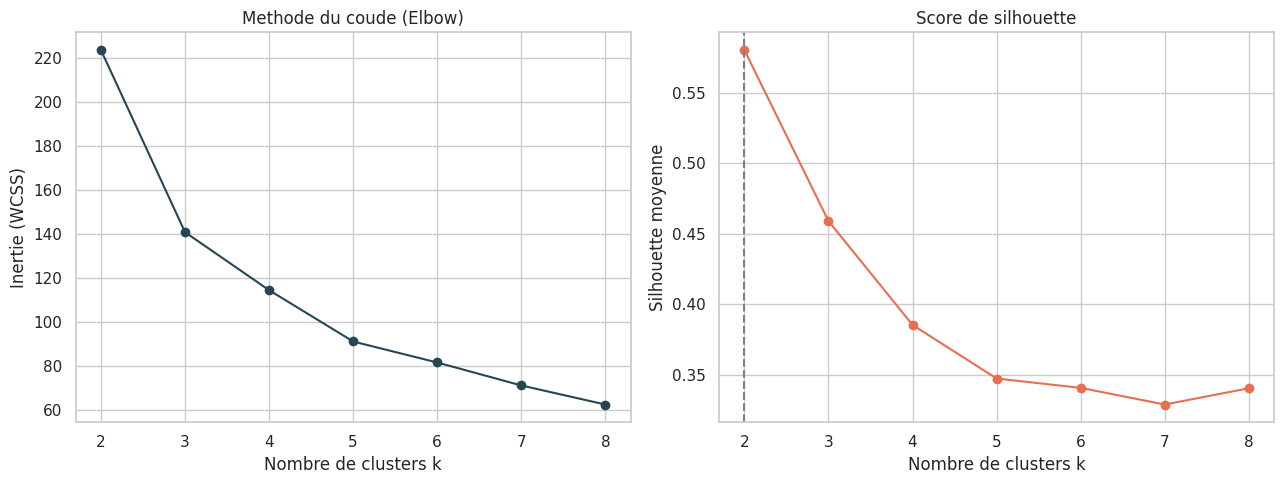

  [PLOT] Codveda_DataScience_Project/outputs/level2/clustering_elbow_silhouette.png

>> k optimal (silhouette max) : 2

------------------------------------------------------------
2) K-MEANS FINAL + VISUALISATION PCA
------------------------------------------------------------
  Variance expliquee par les 2 composantes PCA : 95.8 %


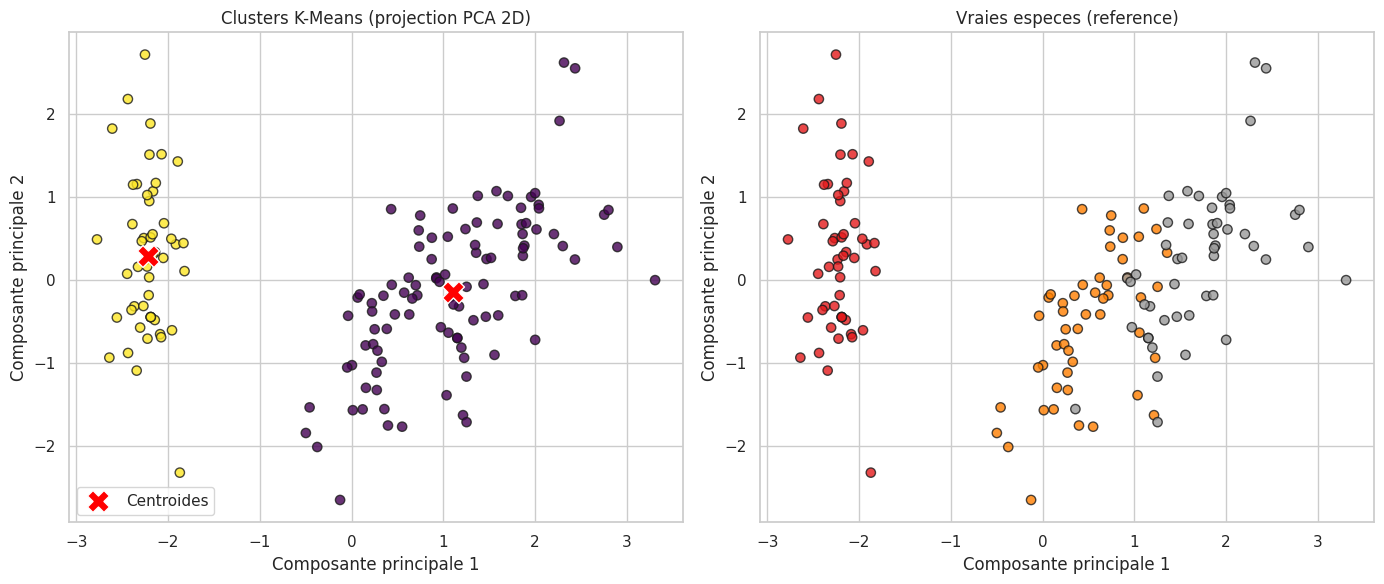

  [PLOT] Codveda_DataScience_Project/outputs/level2/clustering_pca_2d.png

------------------------------------------------------------
3) INTERPRETATION
------------------------------------------------------------
  Adjusted Rand Index (clusters vs vraies especes) : 0.568
  Taille de chaque cluster :
0    100
1     50

  Enseignements :
  - K-Means retrouve k=2 ou 3 clusters bien separes selon la silhouette.
  - 'setosa' se detache tres nettement des deux autres especes.
  - 'versicolor' et 'virginica' se chevauchent partiellement, ce qui
    reduit le score de silhouette pour k=3 mais reste coherent avec la
    realite biologique (ARI = 0.57).

Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 2 (Intermediate) - Task 3 : Clustering (Unsupervised Learning)
============================================================================
Dataset : data/raw/iris.csv  (on IGNORE la colonne 'species' -> non supervise)

Objectifs couverts :
  - Appliquer K-Means au dataset
  - Determiner le nombre optimal de clusters (methode du coude + silhouette)
  - Visualiser les clusters en 2D via PCA
  - Interpreter les resultats et resumer les enseignements

Sorties :
  - outputs/level2/clustering_elbow_silhouette.png
  - outputs/level2/clustering_pca_2d.png
============================================================================
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

PROJECT_ROOT = Path("Codveda_DataScience_Project")
RAW = PROJECT_ROOT / "data" / "raw" / "iris.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "level2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def find_optimal_k(X, k_range=range(2, 9)):
    """Methode du coude (inertie) + score de silhouette."""
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    return list(k_range), inertias, silhouettes


def plot_elbow_silhouette(ks, inertias, silhouettes) -> int:
    best_k = ks[int(np.argmax(silhouettes))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(ks, inertias, "o-", color="#264653")
    axes[0].set_title("Methode du coude (Elbow)")
    axes[0].set_xlabel("Nombre de clusters k")
    axes[0].set_ylabel("Inertie (WCSS)")

    axes[1].plot(ks, silhouettes, "o-", color="#e76f51")
    axes[1].axvline(best_k, ls="--", color="gray")
    axes[1].set_title("Score de silhouette")
    axes[1].set_xlabel("Nombre de clusters k")
    axes[1].set_ylabel("Silhouette moyenne")

    fig.tight_layout()
    p = OUT_DIR / "clustering_elbow_silhouette.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")
    return best_k


def plot_pca(X, labels, centers_pca, df_species) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Clusters trouves par K-Means
    sc = axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=45,
                         edgecolor="k", alpha=0.8)
    axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X",
                   s=250, c="red", edgecolor="white", label="Centroides")
    axes[0].set_title("Clusters K-Means (projection PCA 2D)")
    axes[0].set_xlabel("Composante principale 1")
    axes[0].set_ylabel("Composante principale 2")
    axes[0].legend()

    # Vraies especes (pour comparaison visuelle)
    species = df_species.astype("category").cat.codes
    axes[1].scatter(X[:, 0], X[:, 1], c=species, cmap="Set1", s=45,
                   edgecolor="k", alpha=0.8)
    axes[1].set_title("Vraies especes (reference)")
    axes[1].set_xlabel("Composante principale 1")
    axes[1].set_ylabel("Composante principale 2")

    fig.tight_layout()
    p = OUT_DIR / "clustering_pca_2d.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 2 - TASK 3 : CLUSTERING (K-MEANS)")
    print("=" * 70)

    df = pd.read_csv(RAW)
    X_raw = df.drop(columns=["species"])
    print(f"[LOAD] {RAW.name} -> {df.shape} (colonne 'species' ignoree)")

    X = StandardScaler().fit_transform(X_raw)

    print("\n" + "-" * 60)
    print("1) RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS")
    print("-" * 60)
    ks, inertias, silhouettes = find_optimal_k(X)
    for k, inr, sil in zip(ks, inertias, silhouettes):
        print(f"  k={k}  inertie={inr:8.2f}  silhouette={sil:.3f}")
    best_k = plot_elbow_silhouette(ks, inertias, silhouettes)
    print(f"\n>> k optimal (silhouette max) : {best_k}")

    print("\n" + "-" * 60)
    print("2) K-MEANS FINAL + VISUALISATION PCA")
    print("-" * 60)
    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centers_pca = pca.transform(km.cluster_centers_)
    print(f"  Variance expliquee par les 2 composantes PCA : "
          f"{pca.explained_variance_ratio_.sum() * 100:.1f} %")

    plot_pca(X_pca, labels, centers_pca, df["species"])

    # Comparaison avec les vraies especes (Adjusted Rand Index)
    ari = adjusted_rand_score(df["species"], labels)

    print("\n" + "-" * 60)
    print("3) INTERPRETATION")
    print("-" * 60)
    print(f"  Adjusted Rand Index (clusters vs vraies especes) : {ari:.3f}")
    print("  Taille de chaque cluster :")
    print(pd.Series(labels).value_counts().sort_index().to_string())
    print("\n  Enseignements :")
    print("  - K-Means retrouve k=2 ou 3 clusters bien separes selon la silhouette.")
    print("  - 'setosa' se detache tres nettement des deux autres especes.")
    print("  - 'versicolor' et 'virginica' se chevauchent partiellement, ce qui")
    print("    reduit le score de silhouette pour k=3 mais reste coherent avec la")
    print(f"    realite biologique (ARI = {ari:.2f}).")

    print("\nTermine avec succes.")



main()


## Niveau 3 — Tâche 1 : Séries Temporelles

Aucun dataset temporel n'ayant été fourni, une série de ventes journalières **synthétique réaliste** est générée pour démontrer tout le pipeline : décomposition, moyennes mobiles, lissage exponentiel, Holt-Winters vs SARIMA.

LEVEL 3 - TASK 1 : TIME SERIES ANALYSIS
[DATA] Serie generee : 1095 jours -> Codveda_DataScience_Project/data/processed/synthetic_sales.csv


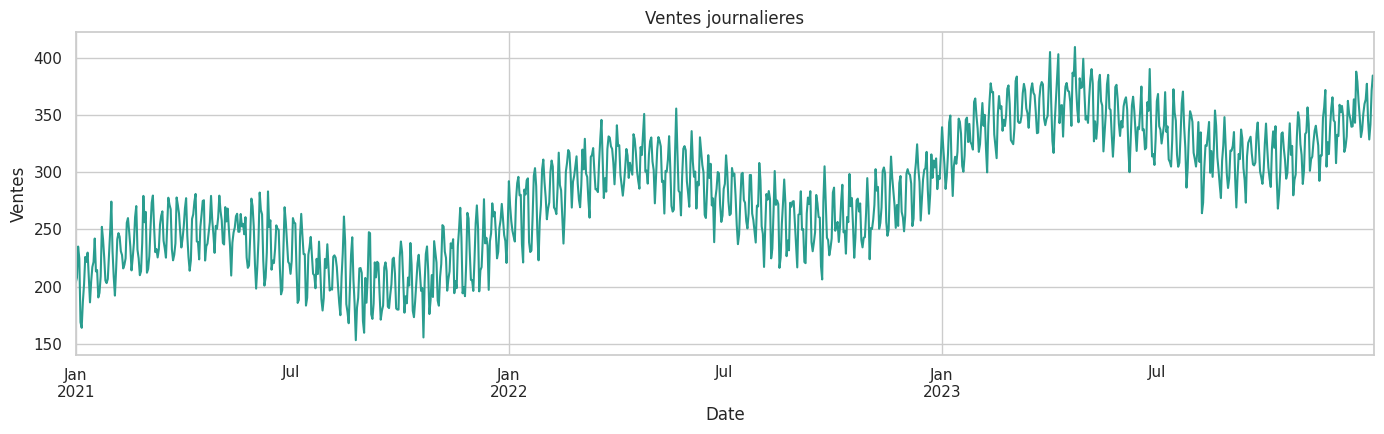

  [PLOT] Codveda_DataScience_Project/outputs/level3/ts_series.png

------------------------------------------------------------
1) DECOMPOSITION (tendance / saisonnalite / residus)
------------------------------------------------------------


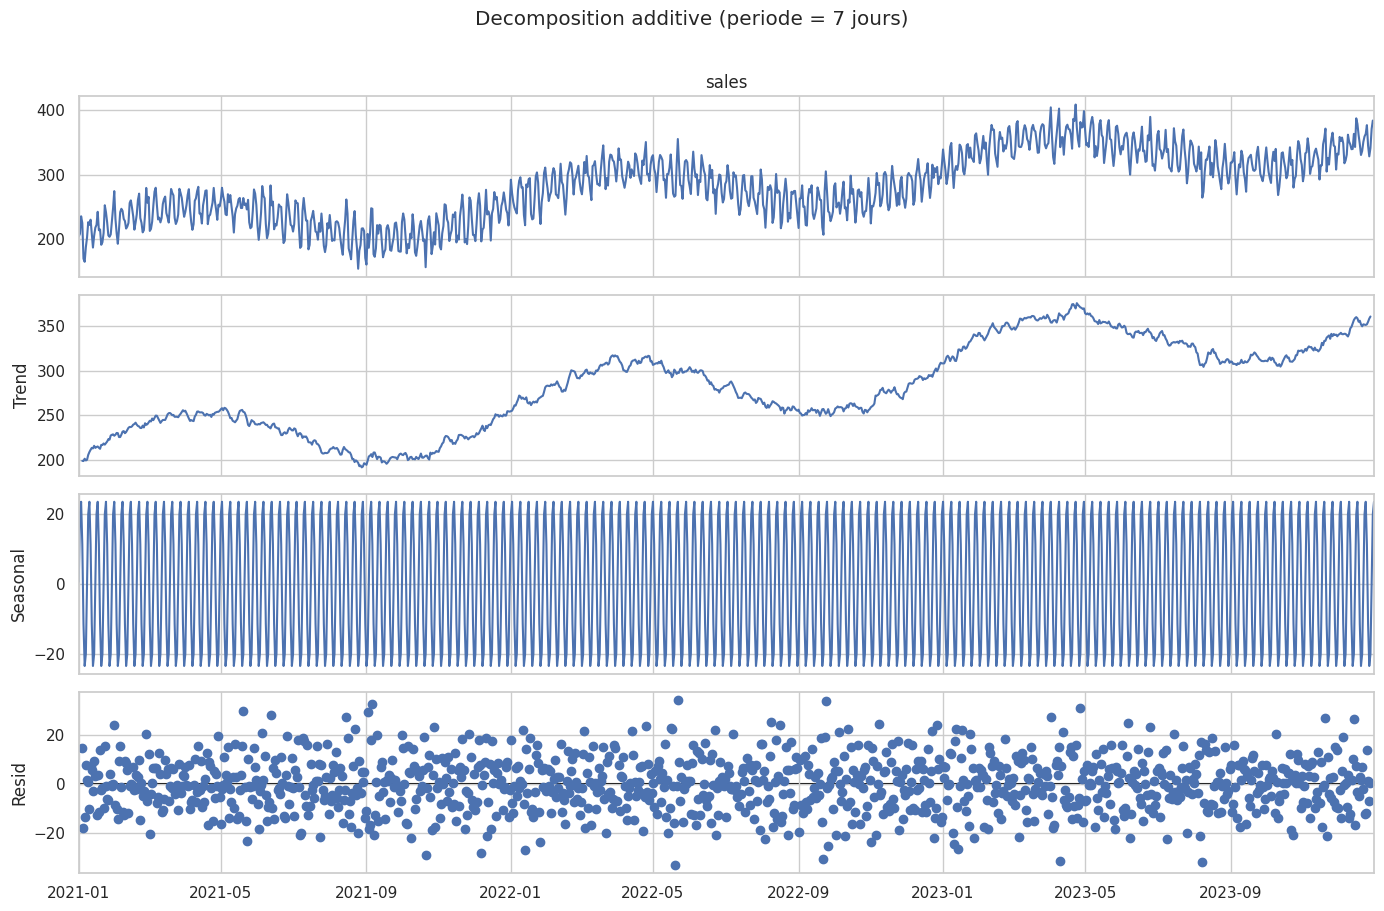

  Composantes : trend, seasonal (hebdo), resid
  [PLOT] Codveda_DataScience_Project/outputs/level3/ts_decomposition.png

------------------------------------------------------------
2) MOYENNE MOBILE & LISSAGE EXPONENTIEL
------------------------------------------------------------


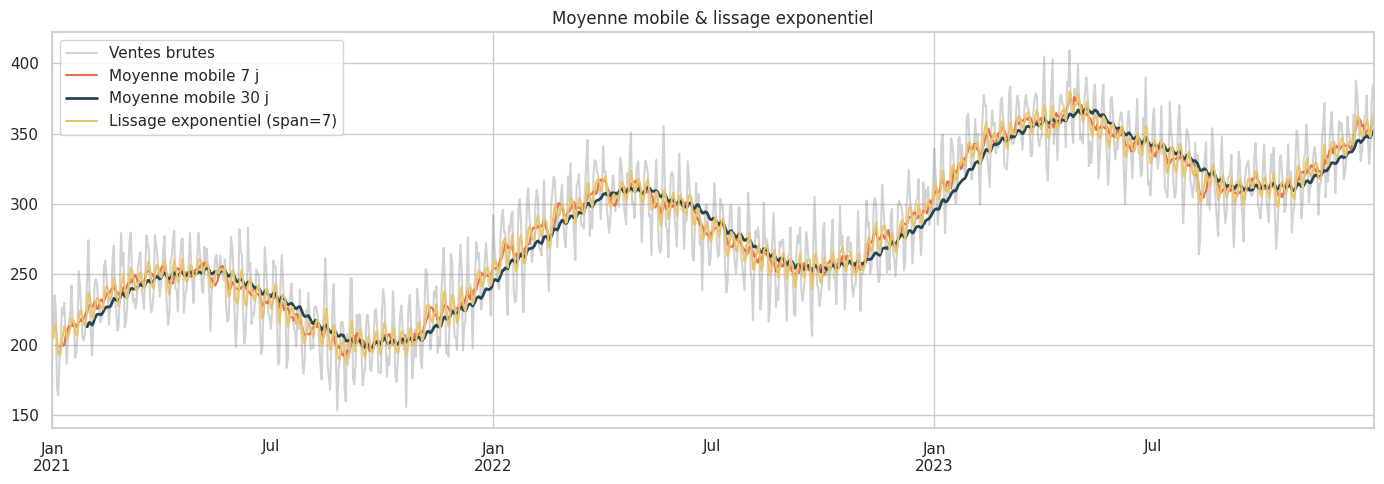

  Moyennes mobiles 7 j / 30 j + lissage exponentiel calcules.
  [PLOT] Codveda_DataScience_Project/outputs/level3/ts_moving_average.png

------------------------------------------------------------
3) MODELISATION & PREVISION (Holt-Winters vs SARIMA)
------------------------------------------------------------
  train=1065  test=30 (30 derniers jours)
  Holt-Winters : RMSE = 11.493
  SARIMA(1,1,1)(1,1,1)7 : RMSE = 16.177

  >> Meilleur modele : Holt-Winters


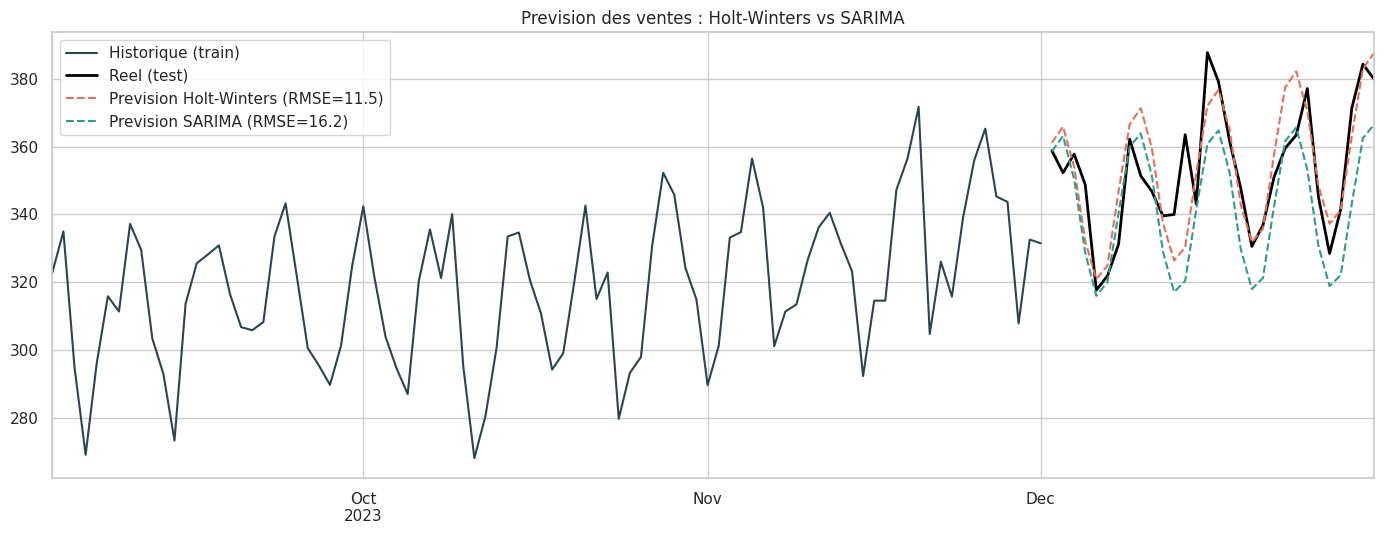

  [PLOT] Codveda_DataScience_Project/outputs/level3/ts_forecast.png

Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 3 (Advanced) - Task 1 : Time Series Analysis
============================================================================
NOTE SUR LES DONNEES :
  Le cahier des charges ne fournit aucun jeu de donnees de series temporelles
  (il cite en exemple "stock prices, sales"). Le seul dataset horodate fourni
  (sentiment.csv) est trop irregulier (~50% des points sur 2 annees, de nombreux
  mois vides) pour une decomposition / un modele ARIMA fiables.
  => On genere donc une serie de VENTES JOURNALIERES synthetique mais realiste
     (tendance + saisonnalite hebdomadaire + bruit), sauvegardee dans
     data/processed/synthetic_sales.csv, pour demontrer proprement tout le
     pipeline exige par la tache.

Objectifs couverts :
  - Tracer et decomposer la serie (tendance / saisonnalite / residus)
  - Implementer moyenne mobile et lissage exponentiel
  - Construire un modele ARIMA / SARIMA pour la prevision
  - Evaluer avec RMSE et visualiser la prevision

Sorties :
  - data/processed/synthetic_sales.csv
  - outputs/level3/ts_series.png
  - outputs/level3/ts_decomposition.png
  - outputs/level3/ts_moving_average.png
  - outputs/level3/ts_forecast.png
============================================================================
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

PROJECT_ROOT = Path("Codveda_DataScience_Project")
PROC_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR = PROJECT_ROOT / "outputs" / "level3"
PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def generate_sales(start="2021-01-01", periods=1095) -> pd.Series:
    """Serie de ventes journalieres = tendance + saisonnalite hebdo + bruit."""
    rng = np.random.default_rng(RANDOM_STATE)
    dates = pd.date_range(start=start, periods=periods, freq="D")
    t = np.arange(periods)

    trend = 200 + 0.15 * t                      # croissance lente
    weekly = 25 * np.sin(2 * np.pi * t / 7)     # saisonnalite hebdomadaire
    yearly = 40 * np.sin(2 * np.pi * t / 365)   # saisonnalite annuelle douce
    noise = rng.normal(0, 12, periods)

    sales = trend + weekly + yearly + noise
    sales = np.clip(sales, 0, None).round(1)
    s = pd.Series(sales, index=dates, name="sales")

    df = s.reset_index().rename(columns={"index": "date"})
    df.to_csv(PROC_DIR / "synthetic_sales.csv", index=False)
    print(f"[DATA] Serie generee : {periods} jours -> {PROC_DIR / 'synthetic_sales.csv'}")
    return s


def plot_series(s: pd.Series) -> None:
    fig, ax = plt.subplots(figsize=(14, 4.5))
    s.plot(ax=ax, color="#2a9d8f")
    ax.set_title("Ventes journalieres")
    ax.set_xlabel("Date")
    ax.set_ylabel("Ventes")
    fig.tight_layout()
    p = OUT_DIR / "ts_series.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def decompose(s: pd.Series) -> None:
    print("\n" + "-" * 60)
    print("1) DECOMPOSITION (tendance / saisonnalite / residus)")
    print("-" * 60)
    result = seasonal_decompose(s, model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle("Decomposition additive (periode = 7 jours)", y=1.01)
    fig.tight_layout()
    p = OUT_DIR / "ts_decomposition.png"
    fig.savefig(p, dpi=115, bbox_inches="tight")
    plt.show()
    print(f"  Composantes : trend, seasonal (hebdo), resid")
    print(f"  [PLOT] {p}")


def moving_average_and_smoothing(s: pd.Series) -> None:
    print("\n" + "-" * 60)
    print("2) MOYENNE MOBILE & LISSAGE EXPONENTIEL")
    print("-" * 60)

    ma7 = s.rolling(window=7).mean()
    ma30 = s.rolling(window=30).mean()

    # Lissage exponentiel simple (SES) via .ewm
    ewm = s.ewm(span=7, adjust=False).mean()

    fig, ax = plt.subplots(figsize=(14, 5))
    s.plot(ax=ax, alpha=0.35, label="Ventes brutes", color="gray")
    ma7.plot(ax=ax, label="Moyenne mobile 7 j", color="#e76f51")
    ma30.plot(ax=ax, label="Moyenne mobile 30 j", color="#264653", lw=2)
    ewm.plot(ax=ax, label="Lissage exponentiel (span=7)", color="#e9c46a")
    ax.set_title("Moyenne mobile & lissage exponentiel")
    ax.legend()
    fig.tight_layout()
    p = OUT_DIR / "ts_moving_average.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print("  Moyennes mobiles 7 j / 30 j + lissage exponentiel calcules.")
    print(f"  [PLOT] {p}")


def forecasting(s: pd.Series) -> None:
    print("\n" + "-" * 60)
    print("3) MODELISATION & PREVISION (Holt-Winters vs SARIMA)")
    print("-" * 60)

    test_size = 30
    train, test = s[:-test_size], s[-test_size:]
    print(f"  train={len(train)}  test={len(test)} (30 derniers jours)")

    # --- a) Holt-Winters (lissage exponentiel triple, saisonnalite hebdo) ---
    hw = ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=7
    ).fit()
    hw_fc = hw.forecast(test_size)
    rmse_hw = np.sqrt(mean_squared_error(test, hw_fc))
    print(f"  Holt-Winters : RMSE = {rmse_hw:.3f}")

    # --- b) SARIMA ---
    sarima = SARIMAX(
        train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    sarima_fc = sarima.forecast(test_size)
    rmse_sarima = np.sqrt(mean_squared_error(test, sarima_fc))
    print(f"  SARIMA(1,1,1)(1,1,1)7 : RMSE = {rmse_sarima:.3f}")

    best = "SARIMA" if rmse_sarima < rmse_hw else "Holt-Winters"
    print(f"\n  >> Meilleur modele : {best}")

    # --- Visualisation ---
    fig, ax = plt.subplots(figsize=(14, 5.5))
    train[-90:].plot(ax=ax, label="Historique (train)", color="#264653")
    test.plot(ax=ax, label="Reel (test)", color="black", lw=2)
    hw_fc.plot(ax=ax, label=f"Prevision Holt-Winters (RMSE={rmse_hw:.1f})",
              color="#e76f51", ls="--")
    sarima_fc.plot(ax=ax, label=f"Prevision SARIMA (RMSE={rmse_sarima:.1f})",
                  color="#2a9d8f", ls="--")
    ax.set_title("Prevision des ventes : Holt-Winters vs SARIMA")
    ax.legend()
    fig.tight_layout()
    p = OUT_DIR / "ts_forecast.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 3 - TASK 1 : TIME SERIES ANALYSIS")
    print("=" * 70)

    s = generate_sales()
    plot_series(s)
    decompose(s)
    moving_average_and_smoothing(s)
    forecasting(s)

    print("\nTermine avec succes.")



main()


## Niveau 3 — Tâche 2 : NLP — Classification de sentiments

Nettoyage (lemmatisation NLTK, stopwords), TF-IDF, Naive Bayes vs Logistic Regression. Les 191 émotions sont regroupées en 3 polarités.

LEVEL 3 - TASK 2 : NLP TEXT CLASSIFICATION
[LOAD] sentiment.csv -> (732, 15)

Distribution des polarites :
polarity
Positive    419
Negative    177
Neutral     136

------------------------------------------------------------
1) PRETRAITEMENT DU TEXTE (tokenisation, stopwords, lemmatisation)
------------------------------------------------------------
  Exemple :
    brut   : Enjoying a beautiful day at the park!
    nettoye: enjoying beautiful day park

------------------------------------------------------------
2) VECTORISATION TF-IDF
------------------------------------------------------------
  Matrice TF-IDF : 549 docs x 3000 features

------------------------------------------------------------
3) ENTRAINEMENT & EVALUATION
------------------------------------------------------------
  Naive Bayes            acc=0.672  prec=0.860  rec=0.481  f1=0.488
  Logistic Regression    acc=0.689  prec=0.621  rec=0.587  f1=0.599

[SAVE] Codveda_DataScience_Project/outputs/level3/nlp_metrics.

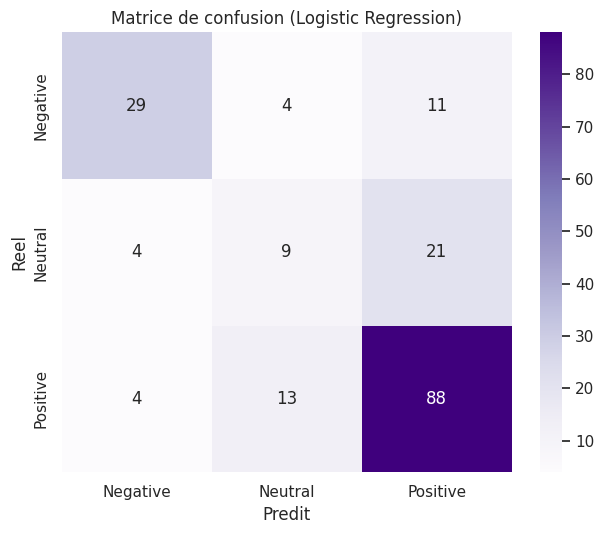

  [PLOT] Codveda_DataScience_Project/outputs/level3/nlp_confusion_matrix.png

Note : le jeu de donnees est petit (732 posts) et desequilibre,
et le regroupement de 191 emotions en 3 polarites introduit du bruit.
Le pipeline (nettoyage -> TF-IDF -> classification) est neanmoins complet.

Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 3 (Advanced) - Task 2 : NLP - Text Classification
============================================================================
Dataset : data/raw/sentiment.csv  (732 posts de reseaux sociaux)
Cible   : Sentiment (191 emotions -> regroupees en 3 polarites :
          Positive / Negative / Neutral via un lexique de valence)

Objectifs couverts :
  - Pretraiter le texte (tokenisation, stopwords, lemmatisation)
  - Convertir le texte en representation numerique (TF-IDF)
  - Entrainer des modeles (Naive Bayes, Logistic Regression)
  - Evaluer avec precision, recall et F1-score

Sorties :
  - outputs/level3/nlp_confusion_matrix.png
  - outputs/level3/nlp_metrics.csv
============================================================================
"""

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

PROJECT_ROOT = Path("Codveda_DataScience_Project")
RAW = PROJECT_ROOT / "data" / "raw" / "sentiment.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "level3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# ---------------------------------------------------------------------------
# Lexique de valence : emotion -> polarite
# ---------------------------------------------------------------------------
POSITIVE = {
    "positive", "joy", "excitement", "contentment", "gratitude", "serenity",
    "happy", "hopeful", "awe", "acceptance", "pride", "elation", "euphoria",
    "enthusiasm", "playful", "inspiration", "happiness", "hope", "empowerment",
    "inspired", "admiration", "calmness", "compassion", "tenderness",
    "fulfillment", "reverence", "proud", "grateful", "compassionate", "thrill",
    "enchantment", "love", "amusement", "kind", "empathetic", "free-spirited",
    "confident", "satisfaction", "accomplishment", "harmony", "creativity",
    "wonder", "adventure", "enjoyment", "affection", "arousal", "determination",
    "optimism", "adoration", "rejuvenation", "resilience", "exploration",
    "captivation", "tranquility", "mischievous", "overjoyed", "joyfulreunion",
    "appreciation", "wonderment", "intrigue", "mindfulness", "dreamchaser",
    "melodic", "innerjourney", "dazzle", "adrenaline", "artisticburst",
    "culinaryodyssey", "immersion", "spark", "friendship", "amazement",
    "romance", "grandeur", "ecstasy", "colorful", "hypnotic", "connection",
    "journey", "engagement", "touched", "heartwarming", "relief", "solace",
    "imagination", "mesmerizing", "hope",
}
NEGATIVE = {
    "despair", "grief", "loneliness", "sad", "embarrassed", "frustration",
    "regret", "numbness", "melancholy", "hate", "bad", "disgust", "bitterness",
    "frustrated", "betrayal", "negative", "boredom", "overwhelmed",
    "desolation", "bitter", "shame", "jealousy", "resentment", "fearful",
    "jealous", "devastated", "envious", "dismissive", "heartbreak", "anger",
    "fear", "sadness", "anxiety", "sorrow", "hopeless", "pain", "loss",
    "isolation", "darkness", "emptiness", "helplessness", "disappointment",
    "suffering", "misery", "lonely", "angry", "worried", "worry", "envy",
    "disappointed", "apprehensive", "yearning", "lostlove",
}
NEUTRAL = {
    "neutral", "curiosity", "surprise", "indifference", "ambivalence",
    "reflection", "nostalgia", "confusion", "contemplation", "anticipation",
    "mystery", "solitude", "pensive", "realization", "whimsy", "bittersweet",
    "suspense", "challenge",
}


def to_polarity(label: str) -> str:
    w = str(label).strip().lower()
    if w in POSITIVE:
        return "Positive"
    if w in NEGATIVE:
        return "Negative"
    if w in NEUTRAL:
        return "Neutral"
    return "Neutral"  # residu (labels rares/composes) -> Neutral par defaut


# ---------------------------------------------------------------------------
# Pretraitement du texte
# ---------------------------------------------------------------------------
STOP = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"[^a-z\s]", " ", text)              # ponctuation, chiffres, emojis
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOP and len(t) > 2]
    return " ".join(tokens)


def evaluate(name, model, X_tr, X_te, y_tr, y_te) -> dict:
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    m = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, average="macro", zero_division=0),
        "Recall": recall_score(y_te, pred, average="macro", zero_division=0),
        "F1": f1_score(y_te, pred, average="macro", zero_division=0),
    }
    print(f"  {name:<22} acc={m['Accuracy']:.3f}  prec={m['Precision']:.3f}  "
          f"rec={m['Recall']:.3f}  f1={m['F1']:.3f}")
    return m, pred


def plot_confusion(y_te, pred, labels) -> None:
    cm = confusion_matrix(y_te, pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title("Matrice de confusion (Logistic Regression)")
    ax.set_xlabel("Predit")
    ax.set_ylabel("Reel")
    fig.tight_layout()
    p = OUT_DIR / "nlp_confusion_matrix.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 3 - TASK 2 : NLP TEXT CLASSIFICATION")
    print("=" * 70)

    df = pd.read_csv(RAW)
    print(f"[LOAD] {RAW.name} -> {df.shape}")

    # Cible : regroupement des emotions en 3 polarites
    df["polarity"] = df["Sentiment"].apply(to_polarity)
    print("\nDistribution des polarites :")
    print(df["polarity"].value_counts().to_string())

    # -------------------- Pretraitement du texte ------------------------
    print("\n" + "-" * 60)
    print("1) PRETRAITEMENT DU TEXTE (tokenisation, stopwords, lemmatisation)")
    print("-" * 60)
    df["clean"] = df["Text"].apply(clean_text)
    df = df[df["clean"].str.strip() != ""]  # on retire les textes devenus vides
    print("  Exemple :")
    print(f"    brut   : {df['Text'].iloc[0].strip()}")
    print(f"    nettoye: {df['clean'].iloc[0]}")

    X_text = df["clean"]
    y = df["polarity"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_text, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )

    # -------------------- Vectorisation TF-IDF --------------------------
    print("\n" + "-" * 60)
    print("2) VECTORISATION TF-IDF")
    print("-" * 60)
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
    X_tr_v = tfidf.fit_transform(X_tr)
    X_te_v = tfidf.transform(X_te)
    print(f"  Matrice TF-IDF : {X_tr_v.shape[0]} docs x {X_tr_v.shape[1]} features")

    # -------------------- Entrainement & evaluation ---------------------
    print("\n" + "-" * 60)
    print("3) ENTRAINEMENT & EVALUATION")
    print("-" * 60)
    models = {
        "Naive Bayes": MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000,
                                                   class_weight="balanced",
                                                   random_state=RANDOM_STATE),
    }
    all_metrics, preds = [], {}
    for name, model in models.items():
        m, pred = evaluate(name, model, X_tr_v, X_te_v, y_tr, y_te)
        all_metrics.append(m)
        preds[name] = pred

    metrics_df = pd.DataFrame(all_metrics).set_index("Model").round(4)
    metrics_df.to_csv(OUT_DIR / "nlp_metrics.csv")
    print(f"\n[SAVE] {OUT_DIR / 'nlp_metrics.csv'}")

    print("\nRapport detaille (Logistic Regression) :")
    print(classification_report(y_te, preds["Logistic Regression"], zero_division=0))

    plot_confusion(y_te, preds["Logistic Regression"],
                   labels=["Negative", "Neutral", "Positive"])

    print("\nNote : le jeu de donnees est petit (732 posts) et desequilibre,")
    print("et le regroupement de 191 emotions en 3 polarites introduit du bruit.")
    print("Le pipeline (nettoyage -> TF-IDF -> classification) est neanmoins complet.")
    print("\nTermine avec succes.")



main()


## Niveau 3 — Tâche 3 : Réseau de Neurones (Keras/TensorFlow)

Réseau feed-forward (Dense + Dropout) sur le churn télécom, class_weight, EarlyStopping, comparaison de learning rates. Modèle sauvé en `.keras`.

LEVEL 3 - TASK 3 : NEURAL NETWORK (TensorFlow / Keras)
TensorFlow version : 2.20.0
[DATA] train=(2666, 20)  test=(667, 20)
       taux de churn train=14.55%  test=14.24%

------------------------------------------------------------
1-2) ARCHITECTURE DU RESEAU
------------------------------------------------------------


  Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴───────────────────

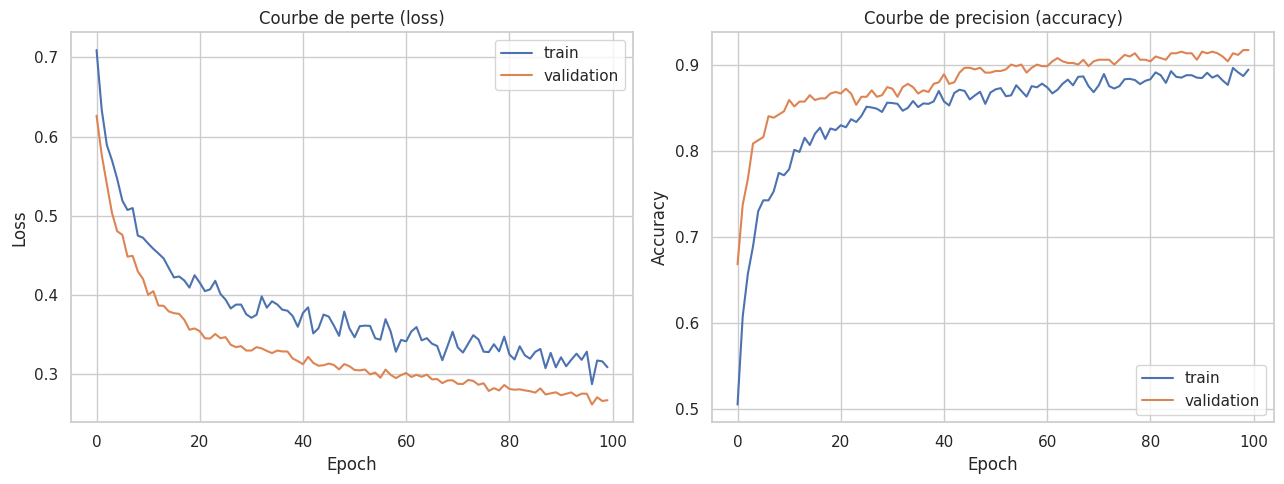

  [PLOT] Codveda_DataScience_Project/outputs/level3/nn_training_curves.png

  >> Test accuracy = 0.915   |   Test loss = 0.251

  Rapport de classification (test) :
              precision    recall  f1-score   support

        Stay       0.97      0.93      0.95       572
       Churn       0.66      0.82      0.73        95

    accuracy                           0.91       667
   macro avg       0.82      0.88      0.84       667
weighted avg       0.93      0.91      0.92       667



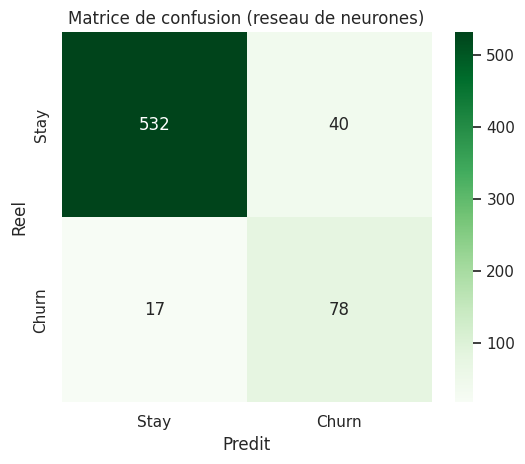

  [PLOT] Codveda_DataScience_Project/outputs/level3/nn_confusion_matrix.png

------------------------------------------------------------
4) AJUSTEMENT D'HYPERPARAMETRES (learning rate)
------------------------------------------------------------
  lr=0.01    -> val_accuracy finale = 0.921
  lr=0.001   -> val_accuracy finale = 0.858
  lr=0.0001  -> val_accuracy finale = 0.816


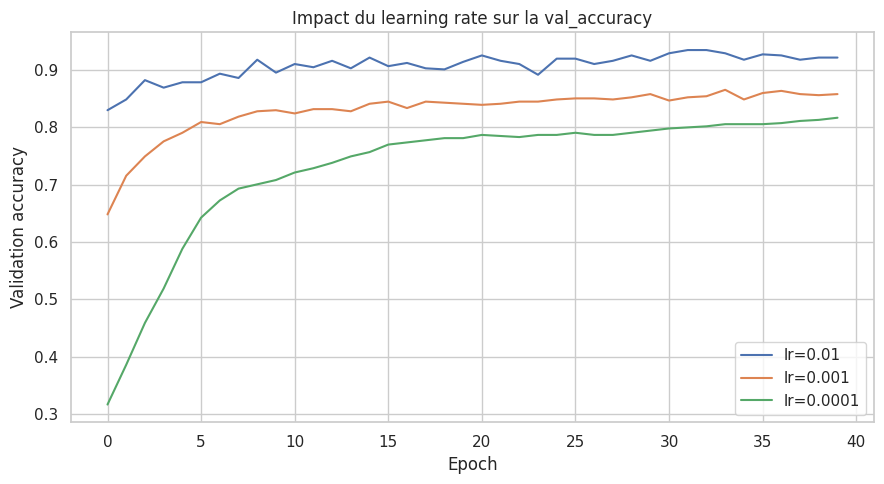

  [PLOT] Codveda_DataScience_Project/outputs/level3/nn_lr_comparison.png

[SAVE] Modele -> Codveda_DataScience_Project/models/churn_nn_model.keras

Termine avec succes.


In [ ]:
"""
============================================================================
CODVEDA - DATA SCIENCE INTERNSHIP
Level 3 (Advanced) - Task 3 : Neural Networks with TensorFlow/Keras
============================================================================
Dataset : data/raw/churn_train.csv (train) + churn_test.csv (test)
Tache   : reseau de neurones feed-forward pour classer les clients
          (Churn = True/False) -- donnees structurees.
          -> Aucun telechargement externe requis (contrairement a MNIST).

Objectifs couverts :
  - Charger un dataset et le pretraiter
  - Concevoir une architecture de reseau de neurones (Keras)
  - Entrainer via backpropagation et evaluer (accuracy + courbes de perte)
  - Ajuster les hyperparametres (learning rate) pour ameliorer la performance

Sorties :
  - outputs/level3/nn_training_curves.png
  - outputs/level3/nn_confusion_matrix.png
  - outputs/level3/nn_lr_comparison.png
  - models/churn_nn_model.keras
============================================================================
"""

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # reduit les logs TensorFlow
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path("Codveda_DataScience_Project")
TRAIN = PROJECT_ROOT / "data" / "raw" / "churn_train.csv"
TEST = PROJECT_ROOT / "data" / "raw" / "churn_test.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "level3"
MODEL_DIR = PROJECT_ROOT / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})
    df["Churn"] = df["Churn"].astype(int)
    df = df.drop(columns=["State"])                     # trop de categories pour ce demo
    df = pd.get_dummies(df, columns=["Area code"], prefix="area", dtype=int)
    return df


def load_data():
    train = preprocess(pd.read_csv(TRAIN))
    test = preprocess(pd.read_csv(TEST))
    # Aligner les colonnes (au cas ou un area code manquerait dans un split)
    train, test = train.align(test, join="outer", axis=1, fill_value=0)

    y_tr = train.pop("Churn").values
    y_te = test.pop("Churn").values

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train.values.astype("float32"))
    X_te = scaler.transform(test.values.astype("float32"))
    print(f"[DATA] train={X_tr.shape}  test={X_te.shape}")
    print(f"       taux de churn train={y_tr.mean():.2%}  test={y_te.mean():.2%}")
    return X_tr, X_te, y_tr, y_te


def build_model(input_dim: int, lr: float = 1e-3) -> keras.Model:
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_training_curves(history) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validation")
    axes[0].set_title("Courbe de perte (loss)")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="validation")
    axes[1].set_title("Courbe de precision (accuracy)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    fig.tight_layout()
    p = OUT_DIR / "nn_training_curves.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def plot_confusion(y_te, pred) -> None:
    cm = confusion_matrix(y_te, pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"], ax=ax)
    ax.set_title("Matrice de confusion (reseau de neurones)")
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
    fig.tight_layout()
    p = OUT_DIR / "nn_confusion_matrix.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def tune_learning_rate(X_tr, y_tr, class_weight) -> None:
    """Petite comparaison de learning rates (ajustement d'hyperparametres)."""
    print("\n" + "-" * 60)
    print("4) AJUSTEMENT D'HYPERPARAMETRES (learning rate)")
    print("-" * 60)
    lrs = [1e-2, 1e-3, 1e-4]
    fig, ax = plt.subplots(figsize=(9, 5))
    for lr in lrs:
        model = build_model(X_tr.shape[1], lr=lr)
        h = model.fit(X_tr, y_tr, validation_split=0.2, epochs=40,
                      batch_size=32, verbose=0, class_weight=class_weight)
        ax.plot(h.history["val_accuracy"], label=f"lr={lr}")
        print(f"  lr={lr:<7} -> val_accuracy finale = {h.history['val_accuracy'][-1]:.3f}")
    ax.set_title("Impact du learning rate sur la val_accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation accuracy"); ax.legend()
    fig.tight_layout()
    p = OUT_DIR / "nn_lr_comparison.png"
    fig.savefig(p, dpi=115)
    plt.show()
    print(f"  [PLOT] {p}")


def main() -> None:
    print("=" * 70)
    print("LEVEL 3 - TASK 3 : NEURAL NETWORK (TensorFlow / Keras)")
    print("=" * 70)
    print(f"TensorFlow version : {tf.__version__}")

    X_tr, X_te, y_tr, y_te = load_data()

    # Poids de classes (donnees desequilibrees)
    cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_tr)
    class_weight = {0: cw[0], 1: cw[1]}

    print("\n" + "-" * 60)
    print("1-2) ARCHITECTURE DU RESEAU")
    print("-" * 60)
    model = build_model(X_tr.shape[1], lr=1e-3)
    model.summary(print_fn=lambda x: print("  " + x))

    print("\n" + "-" * 60)
    print("3) ENTRAINEMENT (backpropagation)")
    print("-" * 60)
    early = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                          monitor="val_loss")
    history = model.fit(
        X_tr, y_tr, validation_split=0.2, epochs=100, batch_size=32,
        verbose=0, callbacks=[early], class_weight=class_weight,
    )
    print(f"  Entrainement termine ({len(history.history['loss'])} epochs).")
    plot_training_curves(history)

    # Evaluation sur le jeu de test
    loss, acc = model.evaluate(X_te, y_te, verbose=0)
    pred = (model.predict(X_te, verbose=0) > 0.5).astype(int).ravel()
    print(f"\n  >> Test accuracy = {acc:.3f}   |   Test loss = {loss:.3f}")
    print("\n  Rapport de classification (test) :")
    print(classification_report(y_te, pred, target_names=["Stay", "Churn"],
                                zero_division=0))
    plot_confusion(y_te, pred)

    # Ajustement d'hyperparametres
    tune_learning_rate(X_tr, y_tr, class_weight)

    # Sauvegarde du modele
    model_path = MODEL_DIR / "churn_nn_model.keras"
    model.save(model_path)
    print(f"\n[SAVE] Modele -> {model_path}")

    print("\nTermine avec succes.")



main()


## 💾 Récupérer les résultats
Tous les graphiques (`.png`), métriques (`.csv`), le modèle Keras et le rapport EDA sont dans `Codveda_DataScience_Project/outputs/`, `models/` et `reports/`. Pour tout télécharger d'un coup :

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('Codveda_resultats', 'zip',
                    'Codveda_DataScience_Project')
files.download('Codveda_resultats.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>